In [1]:
import numpy as np
import pandas as pd

In [2]:
with open('smartprix.html','r',encoding='utf-8') as f:
    html=f.read()

In [3]:
from bs4 import BeautifulSoup

In [4]:
soup = BeautifulSoup(html,'lxml')

In [5]:
containers = soup.find_all('div',{'class':'sm-product has-tag has-features has-actions'})

In [6]:
name = []
prices = []
ratings = []
sim = []
processor = []
ram = []
battery = []
display = []
camera = []
card = []
os = []
for i in soup.find_all('div',{'class':'sm-product has-tag has-features has-actions'}):
    try:
        name.append(i.find('h2').text)
    except:
        name.append(np.nan)
    try:    
        prices.append(i.find('span',{'class':'price'}).text)
    except:
        prices.append(np.nan)
    try:
        ratings.append(i.find('div',{'class':'score rank-2-bg'}).find('b').text)
    except:
        ratings.append(np.nan)
    x = i.find('ul',{'class':'sm-feat specs'}).find_all('li')
    try:
        sim.append(x[0].text)
    except:
        sim.append(np.nan)
    try:
        processor.append(x[1].text)
    except:
        processor.append(np.nan)
    try:
        ram.append(x[2].text)
    except:
        ram.append(np.nan)
    try:
        battery.append(x[3].text)
    except:
        battery.append(np.nan)
    try:
        display.append(x[4].text)
    except:
        display.append(np.nan)
    try:
        camera.append(x[5].text)
    except:
        camera.append(np.nan)
    try:
        card.append(x[6].text)
    except:
        card.append(np.nan)
    try:
        os.append(x[7].text)
    except:
        os.append(np.nan)
        
        

In [7]:
len(name)

1020

In [8]:
len(prices)

1020

In [9]:
len(ratings)

1020

In [10]:
df = pd.DataFrame({
    'model':name,
    'price':prices,
    'rating':ratings,
    'sim':sim,
    'processor':processor,
    'ram':ram,
    'battery':battery,
    'display':display,
    'camera':camera,
    'card':card,
    'os':os
})
df.tail()

,model,price,rating,sim,processor,ram,battery,display,camera,card,os
1015,Jmax Luna,₹995,NaN,"Dual Sim, 3G",No Wifi,"32 MB RAM, 32 MB inbuilt",800 mAh Battery,"0.66 inches, 120 x 240 px Display",No Rear Camera,No FM Radio,Bluetooth
1016,HMD 102,"₹1,269",NaN,Dual Sim,"4 MB RAM, 4 MB inbuilt",1000 mAh Battery with 2.7W Fast Charging,"1.77 inches, 160 x 128 px Display",QVGA Rear Camera,"Memory Card Supported, upto 32 GB",S30+​,NaN
1017,Tryto Boost,₹700,NaN,Dual Sim,250 MHz Processor,"64 MB RAM, 64 MB inbuilt",1000 mAh Battery,"1.8 inches, 128 x 160 px Display",1 MP Rear Camera,No FM Radio,NaN
1018,Jmax A24,"₹1,199",NaN,Dual Sim,No Wifi,500 MHz Processor,"32 MB RAM, 32 MB inbuilt",3000 mAh Battery,"2.4 inches, 320 x 480 px Display",1 MP Rear Camera,Memory Card (Hybrid)
1019,Jmax A18,"₹1,049",NaN,Dual Sim,"32 MB RAM, 32 MB inbuilt",3000 mAh Battery,"1.8 inches, 320 x 480 px Display",0.4 MP Rear Camera,Memory Card (Hybrid),Bluetooth,NaN


In [11]:
df.isnull().sum()

model          0
price          0
rating       391
sim            0
processor      0
ram            0
battery        0
display        0
camera         5
card          19
os            66
dtype: int64

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   model      1020 non-null   str  
 1   price      1020 non-null   str  
 2   rating     629 non-null    str  
 3   sim        1020 non-null   str  
 4   processor  1020 non-null   str  
 5   ram        1020 non-null   str  
 6   battery    1020 non-null   str  
 7   display    1020 non-null   str  
 8   camera     1015 non-null   str  
 9   card       1001 non-null   str  
 10  os         954 non-null    str  
dtypes: str(11)
memory usage: 380.6 KB


In [13]:
with open('samrtphone.xlsx','w',encoding='utf-8') as f:
    f.write(str(df))

In [14]:
df.to_excel('Smartphone.xlsx')

# Data Assessment

## Quality Issues
- ### 1. model - 'Motorola' are also written as 'moto'. `consistency`
- ### 2. model - 'OPPO' is also written as 'Oppo'. `consistency`
- ### 4. model - Phones with only the name 'Xiaomi' are flagship, and phone names with 'Xiaomi Redmi' are budget-friendly.
- ### 5. model - Phones with Honour are flagship, and Peace Honour are budget-friendly.'
- ### 6. price -  Has the '₹' symbol with the price.`validity`
- ### 7. price -  has ',' between the price.`validity`
- ### 8. rating - has missing values.`completness`
- ### 9. sim - In row 931, RAM details are in the SIM column`validity`
- ### 10.sim - In some rows, only the SIM type is mentioned; other specifications are not mentioned.`validity`
- ### 11. processor - In some rows, some specifications are not mentioned.`validity`
- ### 12. processor - In some rows, RAM details are mentioned`validity`
- ### 13. In some rows, battery detail written in the processor column`validity`
- ### 14. Processor - Some processor data is missing in the processor column, but other details are present`Completness`
- ### 15. RAM - Battery specifications are present in some rows.`validity`
- ### 16. RAM - Processor specifications are present in some rows.`validity
- ### 17. battery - In some rows, camera and display information are available.`validity`
- ### 18. os - Some rows have missing values`completness`
- ### 19. os - Some rows have card informations`validity`
- ### 20. card - some rows has os information`validity`
- ### 21. camera - some rows have information from card and display columns`validity`
- ### 22. display - some rrows hs information from the camera and battery columns`validity`
- ### 23. display - sometime frequency is not available. `completness`
- ### 24. Missing values in camera, card, and os `completness`
## Tidiness Issues
- ### 1. model - Brand name and model name are entered in the same column
- ### 2.sim - SIM type, network type,  Wi-Fi, and more specifications are written in the same columns
- ### 3. processor - processor type and clock speed are mentioned in the same column
- ### 4.ram - RAM and storage information are present in the same row
- ### 5. battery- battery capacity and fast charging availability are present in the same column
- ### camera - front and rear camera details are present in the same column.

In [15]:
df.info()
df['rating'] = df['rating'].astype('float64')

<class 'pandas.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   model      1020 non-null   str  
 1   price      1020 non-null   str  
 2   rating     629 non-null    str  
 3   sim        1020 non-null   str  
 4   processor  1020 non-null   str  
 5   ram        1020 non-null   str  
 6   battery    1020 non-null   str  
 7   display    1020 non-null   str  
 8   camera     1015 non-null   str  
 9   card       1001 non-null   str  
 10  os         954 non-null    str  
dtypes: str(11)
memory usage: 380.6 KB


In [16]:
df.describe()

,rating
count,629.000000
mean,63.626391
std,7.951405
min,50.000000
25%,57.000000
50%,64.000000
75%,70.000000
max,79.000000


In [17]:
# make a copy first
df1 = df.copy()

In [18]:
df1['price'] = df1['price'].str.replace('₹','').str.replace(',','').astype('int')

In [19]:
df1 = df1[df1['price'] >= 5900]

In [20]:
processor_rows = set((230,260,286,339,370,373,401,422,431,438,460,464,476,510,516,530,557,575,587,622,624,654,668,685,692,693,711,736,753,757,758,767,771,795,801,802,803,808,812,815,820,821,822,825,826,829,831,850,858,864,865,866,868,872,876,889))


In [21]:
df1 = df1.reset_index()

In [22]:
df1['index'] = df1['index'] + 2

In [23]:
df1[df1['index'].isin(processor_rows)]

,index,model,price,rating,sim,processor,ram,battery,display,camera,card,os
228,230,MTR M17 Max,9600,NaN,"Dual Sim, 4G, Wi-Fi",512 MHz Processor,"3 GB RAM, 32 GB inbuilt",5000 mAh Battery,"6.5 inches, 320 x 480 px Display with Punch Hole",8 MP Rear Camera,Android v12.0,Bluetooth
367,373,Peace Honor 40 Mini,7999,NaN,"Dual Sim, 4G, VoLTE, Wi-Fi",Single Core Processor,"4 GB RAM, 32 GB inbuilt",2000 mAh Battery,"4.5 inches, 412 x 960 px Display",8 MP Rear & 5 MP Front Camera,Android,No FM Radio
756,795,Ringme Bold 26 Ultra,9499,NaN,"Dual Sim, 4G, VoLTE, Wi-Fi",Dual Core Processor,"4 GB RAM, 64 GB inbuilt",5000 mAh Battery,"6.79 inches, 1640 x 720 px Display with Punch ...",13 MP Rear Camera,Android v12,No FM Radio
824,889,Samsung Galaxy A13,15650,NaN,"Dual Sim, 4G, VoLTE, Wi-Fi","Octa Core, 2 GHz Processor","4 GB RAM, 64 GB inbuilt",5000 mAh Battery with 25W Fast Charging,"6.6 inches, 1080 x 2408 px Display with Water ...",50 MP Quad Rear & 8 MP Front Camera,"Memory Card Supported, upto 1 TB",Android v12


In [24]:
df1.to_excel('Smartphone.xlsx',sheet_name='sheet2',)

In [25]:
ram_rows = set((262,529))
df1[df1['index'].isin(ram_rows)]

,index,model,price,rating,sim,processor,ram,battery,display,camera,card,os
259,262,Apple iPhone 16 Plus,76990,70.0,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi","Bionic A18, Hexa Core, 4.04 GHz Processor",128 GB inbuilt,4674 mAh Battery with Fast Charging,"6.7 inches, 1290 x 2796 px Display with Dynami...",48 MP + 12 MP Dual Rear & 12 MP Front Camera,Memory Card Not Supported,iOS v18
514,529,Apple iPhone 16 Plus (256GB),89900,70.0,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi","Bionic A18, Hexa Core, 4.04 GHz Processor",256 GB inbuilt,4674 mAh Battery with Fast Charging,"6.7 inches, 1290 x 2796 px Display with Dynami...",48 MP + 12 MP Dual Rear & 12 MP Front Camera,Memory Card Not Supported,iOS v18


In [26]:
df1

,index,model,price,rating,sim,processor,ram,battery,display,camera,card,os
0,2,Vivo T4 Pro 5G (8GB RAM + 256GB),29999,72.0,"Dual Sim, 5G, VoLTE, Vo5G, Wi-Fi, IR Blaster","Snapdragon 7 Gen4, Octa Core, 2.8 GHz Processor","8 GB RAM, 256 GB inbuilt",6500 mAh Battery with 90W Fast Charging,"6.77 inches, 1080 x 2392 px, 120 Hz Display wi...",50 MP + 50 MP + 2 MP Triple Rear & 32 MP Front...,Memory Card Not Supported,Android v15
1,3,Realme P4s 5G,34999,71.0,"Dual Sim, 5G, VoLTE, Wi-Fi, IR Blaster","Dimensity 7400, Octa Core, 2.6 GHz Processor","8 GB RAM, 128 GB inbuilt",8000 mAh Battery with 80W Fast Charging,"6.78 inches, 1272 x 2772 px, 144 Hz Display wi...",50 MP + 2 MP Dual Rear & 16 MP Front Camera,Memory Card Not Supported,Android v16
2,4,Boltt Ace 5G,12999,53.0,"Dual Sim, 5G, VoLTE, Wi-Fi","Unisoc T8200, Octa Core, 2.3 GHz Processor","4 GB RAM, 64 GB inbuilt",6000 mAh Battery with 18W Fast Charging,"6.79 inches, 720 x 1640 px, 120 Hz Display wit...",64 MP Dual Rear & 8 MP Front Camera,"Memory Card (Hybrid), upto 1 TB",Android v16
3,5,Motorola Edge 70 Fusion,28999,70.0,"Dual Sim, 5G, VoLTE, Vo5G, NFC, Wi-Fi","Snapdragon 7s Gen4, Octa Core, 2.7 GHz Processor","8 GB RAM, 128 GB inbuilt",7000 mAh Battery with 68W Fast Charging,"6.8 inches, 1272 x 2772 px, 144 Hz Display wit...",50 MP + 13 MP + Dedicated 3-in-1 light sensor ...,Android v16,No FM Radio
4,6,Realme P4x 5G,19999,62.0,"Dual Sim, 5G, VoLTE, Wi-Fi","Dimensity 7400 Ultra, Octa Core, 2.6 GHz Proce...","6 GB RAM, 128 GB inbuilt",7000 mAh Battery with 45W Fast Charging,"6.72 inches, 1080 x 2400 px, 144 Hz Display wi...",50 MP + 2 MP Dual Rear & 8 MP Front Camera,Android v15,No FM Radio
...,...,...,...,...,...,...,...,...,...,...,...,...
884,988,Realme 1,12399,NaN,"Dual Sim, 4G, VoLTE, Wi-Fi","Helio P60, Octa Core, 2 GHz Processor","6 GB RAM, 128 GB inbuilt",3410 mAh Battery,"6 inches, 1080 x 2160 px Display",13 MP Rear & 8 MP Front Camera,Memory Card Supported,Android v8.1 (Oreo)
885,989,Apple iPhone 8 Plus (256GB),84900,52.0,"Single Sim, 4G, VoLTE, NFC, Wi-Fi","Apple A11, Hexa Core, 2.39 GHz Processor","3 GB RAM, 256 GB inbuilt",2691 mAh Battery with Fast Charging,"5.5 inches, 1080 x 1920 px Display",12 MP + 12 MP Dual Rear & 7 MP Front Camera,Memory Card Not Supported,iOS v11
886,990,Karbonn Titanium S10,6999,NaN,"Dual Sim, 3G, Wi-Fi","Quad Core, 1.3 GHz Processor","1 GB RAM, 4 GB inbuilt",1850 mAh Battery,"5 inches, 720 x 1280 px Display",8 MP Rear & 2 MP Front Camera,"Memory Card Supported, upto 32 GB",Android v4.4 (KitKat)
887,1011,Peace Honor 10 (4GB RAM + 64GB),8999,NaN,"Dual Sim, 4G, VoLTE, Wi-Fi","Helio, Single Core, 1.3 MHz Processor","4 GB RAM, 64 GB inbuilt",3000 mAh Battery,"4.5 inches, 412 x 960 px Display",8 MP Rear Camera,Android v14.0,No FM Radio


In [27]:
battery_rows = set((505,734))
temp_df = df1[df1['index'].isin(battery_rows)]

In [28]:
temp_df

,index,model,price,rating,sim,processor,ram,battery,display,camera,card,os
492,505,Peace i17 Air,8499,NaN,"Dual Sim, 4G, VoLTE, Wi-Fi",5000 mAh Battery,"6.56 inches, 1640 x 720 px Display",20 MP Rear & 8 MP Front Camera,"Memory Card Supported, upto 128 GB",Android v14.0,No FM Radio,Bluetooth
702,734,Apple iPhone 12 Pro,109900,59.0,"Dual Sim, 5G, VoLTE, NFC, Wi-Fi","Bionic A14, Hexa Core, 3.1 GHz Processor","6 GB RAM, 128 GB inbuilt","6.1 inches, 1170 x 2532 px Display with Large ...",12 MP + 12 MP + 12 MP Triple Rear & 12 MP Fron...,Memory Card Not Supported,iOS v14.0,No FM Radio


In [29]:
x = temp_df.iloc[1:2,7:].shift(1,axis=1).values
y = temp_df.iloc[0:1,7:].shift(2,axis=1).values

In [30]:
df1.loc[514:514,temp_df.columns[7:]].shape

(1, 5)

In [31]:
x.shape

(1, 5)

In [32]:
df1.loc[514:514,temp_df.columns[7:]] = x

In [33]:
df1.loc[259:259,temp_df.columns[7:]] = y

In [34]:
df1[df1['index'].isin(ram_rows)]

,index,model,price,rating,sim,processor,ram,battery,display,camera,card,os
259,262,Apple iPhone 16 Plus,76990,70.0,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi","Bionic A18, Hexa Core, 4.04 GHz Processor",128 GB inbuilt,NaN,NaN,20 MP Rear & 8 MP Front Camera,"Memory Card Supported, upto 128 GB",Android v14.0
514,529,Apple iPhone 16 Plus (256GB),89900,70.0,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi","Bionic A18, Hexa Core, 4.04 GHz Processor",256 GB inbuilt,NaN,"6.1 inches, 1170 x 2532 px Display with Large ...",12 MP + 12 MP + 12 MP Triple Rear & 12 MP Fron...,Memory Card Not Supported,iOS v14.0


In [35]:
display_rows = set((311,373,639,673,674,675,738,794,804,855,857,899,900,901,902,903,920,922,958,975,988,989,990,1011))
df1[df1['index'].isin(display_rows)]

,index,model,price,rating,sim,processor,ram,battery,display,camera,card,os
307,311,Coolpad Cool 20s 5G,14999,NaN,"Dual Sim, 5G, Wi-Fi","Dimensity 700, Octa Core, 2.2 GHz Processor","6 GB RAM, 128 GB inbuilt",4500 mAh Battery with 18W Fast Charging,"6.58 inches, 1080 x 2408 px Display",50 MP + 2 MP Dual Rear & 8 MP Front Camera,Memory Card Supported,Android v13
367,373,Peace Honor 40 Mini,7999,NaN,"Dual Sim, 4G, VoLTE, Wi-Fi",Single Core Processor,"4 GB RAM, 32 GB inbuilt",2000 mAh Battery,"4.5 inches, 412 x 960 px Display",8 MP Rear & 5 MP Front Camera,Android,No FM Radio
616,639,Peace Honor 20 (4GB RAM + 64GB),6499,NaN,"Dual Sim, 4G, VoLTE, Wi-Fi","Helio, Single Core, 1.3 MHz Processor","4 GB RAM, 64 GB inbuilt",2000 mAh Battery,"4.5 inches, 412 x 960 px Display",8 MP Rear & 5 MP Front Camera,Android v12,No FM Radio
647,673,Realme P4 Lite 4G (4GB RAM + 128GB),13917,NaN,"Dual Sim, 4G, Wi-Fi","Unisoc T7250, Octa Core, 1.8 GHz Processor","4 GB RAM, 128 GB inbuilt",6300 mAh Battery with 15W Fast Charging,"6.74 inches, 720 x 1600 px Display",13 MP Rear & 5 MP Front Camera,Memory Card Supported,Android v15
648,674,Peace Nova 17 Pro 4G,7999,NaN,"Dual Sim, 4G, VoLTE, Wi-Fi","MTK6739, Single Core Processor","4 GB RAM, 64 GB inbuilt",5000 mAh Battery,"6.56 inches, 1640 x 720 px Display",20 MP Rear & 8 MP Front Camera,"Memory Card (Hybrid), upto 128 GB",No FM Radio
649,675,Peace Mini 6,5999,NaN,"Dual Sim, 4G, VoLTE, Wi-Fi","Helio, Single Core, 1.3 MHz Processor","3 GB RAM, 32 GB inbuilt",2000 mAh Battery,"3.75 inches, 412 x 960 px Display",8 MP Rear Camera,Android v12.0,No FM Radio
705,738,Apple iPhone 8 Plus,49900,NaN,"Single Sim, 4G, VoLTE, NFC, Wi-Fi","Apple A11, Hexa Core, 2.39 GHz Processor","3 GB RAM, 64 GB inbuilt",2691 mAh Battery with Fast Charging,"5.5 inches, 1080 x 1920 px Display",12 MP + 12 MP Dual Rear & 7 MP Front Camera,Memory Card Not Supported,iOS v11
755,794,Peace I17 Pro,8499,NaN,"Dual Sim, 4G, VoLTE, Wi-Fi",Helio MT8125,"6 GB RAM, 128 GB inbuilt",5000 mAh Battery,"6.6 inches, 1440 x 720 px Display",20 MP Rear & 8 MP Front Camera,"Memory Card Supported, upto 128 GB",Android v12
762,804,Apple iPhone Air (1TB),141900,67.0,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi","Apple A19 Pro, Hexa Core Processor","8 GB RAM, 1 TB inbuilt",3149 mAh Battery with Fast Charging,"6.5 inches, 1260 x 2736 px Display with Dynami...",48 MP Rear & 18 MP Front Camera,Memory Card Not Supported,iOS v26
799,855,Realme P4 Lite 4G,12799,NaN,"Dual Sim, 4G, Wi-Fi","Unisoc T7250, Octa Core, 1.8 GHz Processor","4 GB RAM, 64 GB inbuilt",6300 mAh Battery with 15W Fast Charging,"6.74 inches, 720 x 1600 px Display",13 MP Rear & 5 MP Front Camera,Memory Card Supported,Android v15


In [36]:
df1[df1['index'] == 505]

,index,model,price,rating,sim,processor,ram,battery,display,camera,card,os
492,505,Peace i17 Air,8499,NaN,"Dual Sim, 4G, VoLTE, Wi-Fi",5000 mAh Battery,"6.56 inches, 1640 x 720 px Display",20 MP Rear & 8 MP Front Camera,"Memory Card Supported, upto 128 GB",Android v14.0,No FM Radio,Bluetooth


In [37]:
df1.loc[492,'processor'] = np.nan
df1.loc[492,'ram'] = np.nan
df1.loc[492,'battery'] = '5000 mAh Battery'
df1.loc[492,'display'] = '6.56 inches, 1640 x 720 px Display'
df1.loc[492,'camera'] = '20 MP Rear & 8 MP Front Camera'
df1.loc[492,'os'] = 'Android v14.0'
df1.loc[492,'card'] = 'Memory Card Supported, upto 128 GB,No FM Radio,Bluetooth'

In [38]:
df1.iloc[702:703,7:] = df1.iloc[702:703,7:].shift(1,axis=1)

In [39]:
camera_rows = set((220,280,395,428,444,471,544,559,576,582,583,614,619,628,653,665,688,713,722,742,743,752,768,774,796,807,817,851,861,871,875,927,928,944))
temp_df = df1[df1['index'].isin(camera_rows)]

In [40]:
df1.loc[temp_df.index,'camera'] = temp_df['card'].values

In [41]:
temp_df = df1[df1['card'].str.contains('MP')]

In [42]:
df1.loc[temp_df.index,'card'] = 'Memory Card Not Supported'

In [43]:
temp_df = df1[~df1['card'].str.contains('Memory Card')]

In [44]:
df1.loc[temp_df.index,'os'] = temp_df['card'].values

In [45]:
df1.loc[temp_df.index,'card'] = 'Memory Card Not Supported'

In [46]:
df1['card'].value_counts()

card
Memory Card Not Supported                                   431
Memory Card (Hybrid), upto 1 TB                             111
Memory Card Supported, upto 1 TB                             77
Memory Card (Hybrid), upto 2 TB                              72
Memory Card (Hybrid)                                         63
Memory Card Supported                                        46
Memory Card Supported, upto 2 TB                             30
Memory Card Supported, upto 256 GB                           21
Memory Card Supported, upto 512 GB                           18
Memory Card (Hybrid), upto 1.5 TB                             8
Memory Card Supported, upto 128 GB                            4
Memory Card (Hybrid), upto 256 GB                             2
Memory Card (Hybrid), upto 128 GB                             2
Memory Card (Hybrid), upto 512 GB                             2
Memory Card Supported, upto 128 GB,No FM Radio,Bluetooth      1
Memory Card Supported, upto 32 GB  

In [47]:
df1['os'].value_counts()

os
Android v16                  268
Android v15                  258
Android v14                   97
Android v12                   64
Android v13                   49
Android v11                   44
Memory Card Not Supported     19
Android v10                   18
iOS v26                       12
Android v17                   12
iOS v18                        7
Android v9.0 (Pie)             5
Android v8.1 (Oreo)            5
Android v10.0                  4
iOS v17                        3
Android v14.0                  3
iOS v26.3                      2
Android v12.0                  2
iOS v14.0                      2
Android 15 Go                  2
Android 15 Go Edition          2
No FM Radio                    2
iOS v11                        2
iOS v15                        1
v60                            1
Android                        1
Memory Card (Hybrid)           1
Android v13.0                  1
Android v7.1.1 (Nougat)        1
Android v4.4 (KitKat)          1
Name: c

In [48]:
temp_df = df1[df1['os'].isin(['Memory Card (Hybrid)','Memory Card Not Supported'])]

In [49]:
df1.loc[temp_df.index,'card'] = temp_df['os'].values

In [50]:
df1.loc[temp_df.index,'os'] = np.nan

In [51]:
df1.loc[df1[df1['os'] == 'No FM Radio'].index,'os'] = np.nan

In [52]:
df1['display'].value_counts()

display
6.67 inches, 1080 x 2400 px, 120 Hz Display with Punch Hole    31
6.7 inches, 1080 x 2340 px, 120 Hz Display with Punch Hole     26
6.77 inches, 1080 x 2392 px, 120 Hz Display with Punch Hole    20
6.75 inches, 720 x 1570 px, 120 Hz Display with Punch Hole     18
6.57 inches, 1080 x 2372 px, 120 Hz Display with Punch Hole    16
                                                               ..
6.4 inches, 1080 x 2340 px Display with Water Drop Notch        1
6.22 inches, 1520 x 720 px Display with Water Drop Notch        1
6.2 inches, 720 x 1520 px Display with Small Notch              1
6 inches, 1080 x 2160 px Display                                1
5 inches, 720 x 1280 px Display                                 1
Name: count, Length: 256, dtype: int64

In [53]:
df1.head()

,index,model,price,rating,sim,processor,ram,battery,display,camera,card,os
0,2,Vivo T4 Pro 5G (8GB RAM + 256GB),29999,72.0,"Dual Sim, 5G, VoLTE, Vo5G, Wi-Fi, IR Blaster","Snapdragon 7 Gen4, Octa Core, 2.8 GHz Processor","8 GB RAM, 256 GB inbuilt",6500 mAh Battery with 90W Fast Charging,"6.77 inches, 1080 x 2392 px, 120 Hz Display wi...",50 MP + 50 MP + 2 MP Triple Rear & 32 MP Front...,Memory Card Not Supported,Android v15
1,3,Realme P4s 5G,34999,71.0,"Dual Sim, 5G, VoLTE, Wi-Fi, IR Blaster","Dimensity 7400, Octa Core, 2.6 GHz Processor","8 GB RAM, 128 GB inbuilt",8000 mAh Battery with 80W Fast Charging,"6.78 inches, 1272 x 2772 px, 144 Hz Display wi...",50 MP + 2 MP Dual Rear & 16 MP Front Camera,Memory Card Not Supported,Android v16
2,4,Boltt Ace 5G,12999,53.0,"Dual Sim, 5G, VoLTE, Wi-Fi","Unisoc T8200, Octa Core, 2.3 GHz Processor","4 GB RAM, 64 GB inbuilt",6000 mAh Battery with 18W Fast Charging,"6.79 inches, 720 x 1640 px, 120 Hz Display wit...",64 MP Dual Rear & 8 MP Front Camera,"Memory Card (Hybrid), upto 1 TB",Android v16
3,5,Motorola Edge 70 Fusion,28999,70.0,"Dual Sim, 5G, VoLTE, Vo5G, NFC, Wi-Fi","Snapdragon 7s Gen4, Octa Core, 2.7 GHz Processor","8 GB RAM, 128 GB inbuilt",7000 mAh Battery with 68W Fast Charging,"6.8 inches, 1272 x 2772 px, 144 Hz Display wit...",50 MP + 13 MP + Dedicated 3-in-1 light sensor ...,Memory Card Not Supported,Android v16
4,6,Realme P4x 5G,19999,62.0,"Dual Sim, 5G, VoLTE, Wi-Fi","Dimensity 7400 Ultra, Octa Core, 2.6 GHz Proce...","6 GB RAM, 128 GB inbuilt",7000 mAh Battery with 45W Fast Charging,"6.72 inches, 1080 x 2400 px, 144 Hz Display wi...",50 MP + 2 MP Dual Rear & 8 MP Front Camera,Memory Card Not Supported,Android v15


In [54]:
brand_names = df['model'].str.split(" ").str.get(0)

In [55]:
df1.insert(1,'brand_name',brand_names)

In [56]:
df1.head()

,index,brand_name,model,price,rating,sim,processor,ram,battery,display,camera,card,os
0,2,Vivo,Vivo T4 Pro 5G (8GB RAM + 256GB),29999,72.0,"Dual Sim, 5G, VoLTE, Vo5G, Wi-Fi, IR Blaster","Snapdragon 7 Gen4, Octa Core, 2.8 GHz Processor","8 GB RAM, 256 GB inbuilt",6500 mAh Battery with 90W Fast Charging,"6.77 inches, 1080 x 2392 px, 120 Hz Display wi...",50 MP + 50 MP + 2 MP Triple Rear & 32 MP Front...,Memory Card Not Supported,Android v15
1,3,Realme,Realme P4s 5G,34999,71.0,"Dual Sim, 5G, VoLTE, Wi-Fi, IR Blaster","Dimensity 7400, Octa Core, 2.6 GHz Processor","8 GB RAM, 128 GB inbuilt",8000 mAh Battery with 80W Fast Charging,"6.78 inches, 1272 x 2772 px, 144 Hz Display wi...",50 MP + 2 MP Dual Rear & 16 MP Front Camera,Memory Card Not Supported,Android v16
2,4,Boltt,Boltt Ace 5G,12999,53.0,"Dual Sim, 5G, VoLTE, Wi-Fi","Unisoc T8200, Octa Core, 2.3 GHz Processor","4 GB RAM, 64 GB inbuilt",6000 mAh Battery with 18W Fast Charging,"6.79 inches, 720 x 1640 px, 120 Hz Display wit...",64 MP Dual Rear & 8 MP Front Camera,"Memory Card (Hybrid), upto 1 TB",Android v16
3,5,Motorola,Motorola Edge 70 Fusion,28999,70.0,"Dual Sim, 5G, VoLTE, Vo5G, NFC, Wi-Fi","Snapdragon 7s Gen4, Octa Core, 2.7 GHz Processor","8 GB RAM, 128 GB inbuilt",7000 mAh Battery with 68W Fast Charging,"6.8 inches, 1272 x 2772 px, 144 Hz Display wit...",50 MP + 13 MP + Dedicated 3-in-1 light sensor ...,Memory Card Not Supported,Android v16
4,6,Realme,Realme P4x 5G,19999,62.0,"Dual Sim, 5G, VoLTE, Wi-Fi","Dimensity 7400 Ultra, Octa Core, 2.6 GHz Proce...","6 GB RAM, 128 GB inbuilt",7000 mAh Battery with 45W Fast Charging,"6.72 inches, 1080 x 2400 px, 144 Hz Display wi...",50 MP + 2 MP Dual Rear & 8 MP Front Camera,Memory Card Not Supported,Android v15


In [57]:
df1['brand_name'] = df1['brand_name'].str.lower()

In [58]:
df1['brand_name'].value_counts()

brand_name
samsung     147
realme      104
oppo         96
vivo         76
xiaomi       63
motorola     61
poco         50
oneplus      31
apple        29
lava         26
google       23
iqoo         21
infinix      21
tecno        17
nothing      16
ai+          16
nokia        13
itel         13
hmd           9
jio           8
peace         7
boltt         5
alcatel       5
mtr           3
ikall         3
philips       3
micromax      3
moto          2
coolpad       2
karbonn       2
gfive         2
wobble        2
foneme        2
ringme        2
honor         1
samaung       1
snexian       1
acer          1
amaq          1
asus          1
Name: count, dtype: int64

In [59]:
has_5g = df1['sim'].str.contains('5G')
has_nfc = df1['sim'].str.contains('NFC')
has_ir_blaster = df1['sim'].str.contains('IR Blaster')

In [60]:
df1.insert(6,'has_5g',has_5g)
df1.insert(7,'has_nfc',has_nfc)
df1.insert(8,'has_ir_blaster',has_ir_blaster)

In [61]:
processor_name = df1['processor'].str.split(",").str.get(0)

In [62]:
num_core = df1['processor'].str.split(",").str.get(1)

In [63]:
processor_speed = df1['processor'].str.split(",").str.get(2)

In [64]:
df1.insert(10,'processor_name',processor_name)
df1.insert(11,'num_core',num_core)
df1.insert(12,'processor_speed',processor_speed)

In [65]:
df1['processor_name'].value_counts()

processor_name
Dimensity 6300        124
Unisoc T7250           22
Snapdragon 7s Gen4     19
Snapdragon 7 Gen4      17
Dimensity 7400         17
                     ... 
Snapdragon  665         1
Helio P70               1
Snapdragon 450          1
Helio P60               1
Quad Core               1
Name: count, Length: 220, dtype: int64

In [66]:
df1 = df1[~(df1['index'] == 505)]

In [67]:
temp_df = df1[df1['processor_name'].str.contains('Core')][['processor_name','num_core','processor_speed']].shift(1,axis=1)

In [68]:
df1.loc[temp_df.index,['processor_name','num_core','processor_speed']] = temp_df.values

In [69]:
df1.loc[856,'processor_name'] = 'Mediatek MT6739'

In [70]:
processor_brand = df1['processor_name'].str.split(" ").str.get(0).str.lower()

In [71]:
df1.insert(11,'processor_brand',processor_brand)

In [72]:
changes = {'apple':'bionic',
'helio':'mediatek',
'dimensity':'mediatek',
'mtk6739':'mediatek',
'snapdragon':'qualcomm',
'tiger':'unisoc',
'sc9863a':'unisoc'}
df1['processor_brand'] = df1['processor_brand'].replace(changes)

In [73]:
df1.loc[228,'processor_brand'] = 'mediatek'
df1.loc[228,'processor_speed'] = 0.512
df1.loc[780,'processor_brand'] = 'qualcomm'

In [74]:
df1['num_core'] = df1['num_core'].str.strip()

In [75]:
df1['num_core'] = df1['num_core'].replace('Octa Core Processor','Octa Core')
df1['num_core'] = df1['num_core'].replace('Hexa Core Processor','Hexa Core')
df1['num_core'] = df1['num_core'].replace('Single Core Processor','Single Core')
df1['num_core'] = df1['num_core'].replace('Nine-Cores','Nine Core')
df1['num_core'] = df1['num_core'].replace('Nine Cores','Nine Core')

In [76]:
temp_df = df1[df1['num_core'] == "0.512 Ghz Processor"]

In [77]:
df1.loc[temp_df.index,'num_core'] = "Quad Core"

In [78]:
df1.loc[temp_df.index,'processor_speed'] = "512 MHz Processor"

In [79]:
df1['processor_speed'] = df1['processor_speed'].str.strip().str.split(" ").str.get(0)

In [80]:
df1['processor_speed'] = df1['processor_speed'].astype('float64')

In [81]:
df1.processor_speed.value_counts()

processor_speed
2.40    220
2.50     77
2.20     62
2.60     53
2.30     40
2.00     37
1.80     33
3.20     29
2.80     26
2.70     22
3.00     22
3.35     19
3.80     18
3.40     13
3.25     11
3.30     11
4.47     10
2.90     10
4.74      9
3.10      9
4.60      8
2.84      8
4.04      7
1.60      7
2.05      6
3.63      5
4.21      4
3.78      4
4.32      4
2.63      4
3.73      4
2.85      4
3.36      4
1.30      4
3.46      3
3.11      2
4.05      2
1.70      2
2.96      2
2.39      2
3.22      1
3.84      1
3.39      1
2.73      1
2.10      1
Name: count, dtype: int64

In [82]:
df1.info()

<class 'pandas.DataFrame'>
Index: 888 entries, 0 to 888
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   index            888 non-null    int64  
 1   brand_name       888 non-null    object 
 2   model            888 non-null    str    
 3   price            888 non-null    int64  
 4   rating           629 non-null    float64
 5   sim              888 non-null    str    
 6   has_5g           888 non-null    bool   
 7   has_nfc          888 non-null    bool   
 8   has_ir_blaster   888 non-null    bool   
 9   processor        888 non-null    str    
 10  processor_name   883 non-null    object 
 11  processor_brand  883 non-null    object 
 12  num_core         879 non-null    object 
 13  processor_speed  822 non-null    float64
 14  ram              888 non-null    str    
 15  battery          885 non-null    str    
 16  display          887 non-null    str    
 17  camera           888 non-null   

In [83]:
ram_capacity = df1['ram'].str.strip().str.split(" ").str.get(0)

In [84]:
df1.insert(15,'ram_capacity',ram_capacity)

In [85]:
internal_memory = df1['ram'].str.strip().str.split(" ").str.get(3)

In [86]:
df1.insert(16,'internal_memory',internal_memory)

In [87]:
df1.head()

,index,brand_name,model,price,rating,sim,has_5g,has_nfc,has_ir_blaster,processor,...,num_core,processor_speed,ram,ram_capacity,internal_memory,battery,display,camera,card,os
0,2,vivo,Vivo T4 Pro 5G (8GB RAM + 256GB),29999,72.0,"Dual Sim, 5G, VoLTE, Vo5G, Wi-Fi, IR Blaster",True,False,True,"Snapdragon 7 Gen4, Octa Core, 2.8 GHz Processor",...,Octa Core,2.8,"8 GB RAM, 256 GB inbuilt",8,256,6500 mAh Battery with 90W Fast Charging,"6.77 inches, 1080 x 2392 px, 120 Hz Display wi...",50 MP + 50 MP + 2 MP Triple Rear & 32 MP Front...,Memory Card Not Supported,Android v15
1,3,realme,Realme P4s 5G,34999,71.0,"Dual Sim, 5G, VoLTE, Wi-Fi, IR Blaster",True,False,True,"Dimensity 7400, Octa Core, 2.6 GHz Processor",...,Octa Core,2.6,"8 GB RAM, 128 GB inbuilt",8,128,8000 mAh Battery with 80W Fast Charging,"6.78 inches, 1272 x 2772 px, 144 Hz Display wi...",50 MP + 2 MP Dual Rear & 16 MP Front Camera,Memory Card Not Supported,Android v16
2,4,boltt,Boltt Ace 5G,12999,53.0,"Dual Sim, 5G, VoLTE, Wi-Fi",True,False,False,"Unisoc T8200, Octa Core, 2.3 GHz Processor",...,Octa Core,2.3,"4 GB RAM, 64 GB inbuilt",4,64,6000 mAh Battery with 18W Fast Charging,"6.79 inches, 720 x 1640 px, 120 Hz Display wit...",64 MP Dual Rear & 8 MP Front Camera,"Memory Card (Hybrid), upto 1 TB",Android v16
3,5,motorola,Motorola Edge 70 Fusion,28999,70.0,"Dual Sim, 5G, VoLTE, Vo5G, NFC, Wi-Fi",True,True,False,"Snapdragon 7s Gen4, Octa Core, 2.7 GHz Processor",...,Octa Core,2.7,"8 GB RAM, 128 GB inbuilt",8,128,7000 mAh Battery with 68W Fast Charging,"6.8 inches, 1272 x 2772 px, 144 Hz Display wit...",50 MP + 13 MP + Dedicated 3-in-1 light sensor ...,Memory Card Not Supported,Android v16
4,6,realme,Realme P4x 5G,19999,62.0,"Dual Sim, 5G, VoLTE, Wi-Fi",True,False,False,"Dimensity 7400 Ultra, Octa Core, 2.6 GHz Proce...",...,Octa Core,2.6,"6 GB RAM, 128 GB inbuilt",6,128,7000 mAh Battery with 45W Fast Charging,"6.72 inches, 1080 x 2400 px, 144 Hz Display wi...",50 MP + 2 MP Dual Rear & 8 MP Front Camera,Memory Card Not Supported,Android v15


In [88]:
df1['ram_capacity'].value_counts()

ram_capacity
8      329
4      188
12     172
6      144
16      28
3       19
2        4
128      1
256      1
18       1
1        1
Name: count, dtype: int64

In [89]:
temp_df = df1[df1['ram_capacity'] == '128']

In [90]:
df1.loc[temp_df.index,['ram_capacity']] = "8"

In [91]:
df1.loc[temp_df.index,['internal_memory']] = "128"

In [92]:
df1.loc[temp_df.index,['internal_memory']]

,internal_memory
259,128


In [93]:
temp_df = df1[df1['ram_capacity'] == '256']

In [94]:
df1.loc[temp_df.index,['ram_capacity']] = "8"
df1.loc[temp_df.index,['internal_memory']] = "256"

In [95]:
df1.loc[temp_df.index,['ram_capacity']]

,ram_capacity
514,8


In [96]:
df1['internal_memory'].value_counts()

internal_memory
128    389
256    293
64     119
512     63
32      11
1        9
16       2
2        1
4        1
Name: count, dtype: int64

In [97]:
df1[df1['internal_memory'] == '16']

,index,brand_name,model,price,rating,sim,has_5g,has_nfc,has_ir_blaster,processor,...,num_core,processor_speed,ram,ram_capacity,internal_memory,battery,display,camera,card,os
311,315,samsung,Realme C2,6999,NaN,"Dual Sim, 4G, VoLTE, Wi-Fi",False,False,False,"Helio P22, Octa Core, 2 GHz Processor",...,Octa Core,2.0,"2 GB RAM, 16 GB inbuilt",2,16,4000 mAh Battery,"6.1 inches, 1560 x 720 px Display with Water D...",13 MP + 2 MP Dual Rear & 5 MP Front Camera,"Memory Card Supported, upto 256 GB",Android v9.0 (Pie)
800,857,ikall,Foneme F17 Pro,5900,NaN,"Dual Sim, 4G, Wi-Fi",False,False,False,"Helio, 512 MHz Processor",...,512 MHz Processor,NaN,"2 GB RAM, 16 GB inbuilt",2,16,2000 mAh Battery with Fast Charging,"4 inches, 480 x 320 px Display",5 MP Rear & 2 MP Front Camera,Memory Card Not Supported,Android v8.1 (Oreo)


In [98]:
df1['internal_memory'] = df1['internal_memory'].replace('1','1024')

In [99]:
df1['internal_memory'] = df1['internal_memory'].replace('2','2048')

In [100]:
df1['internal_memory'].value_counts()

internal_memory
128     389
256     293
64      119
512      63
32       11
1024      9
16        2
2048      1
4         1
Name: count, dtype: int64

In [101]:
df1.head()

,index,brand_name,model,price,rating,sim,has_5g,has_nfc,has_ir_blaster,processor,...,num_core,processor_speed,ram,ram_capacity,internal_memory,battery,display,camera,card,os
0,2,vivo,Vivo T4 Pro 5G (8GB RAM + 256GB),29999,72.0,"Dual Sim, 5G, VoLTE, Vo5G, Wi-Fi, IR Blaster",True,False,True,"Snapdragon 7 Gen4, Octa Core, 2.8 GHz Processor",...,Octa Core,2.8,"8 GB RAM, 256 GB inbuilt",8,256,6500 mAh Battery with 90W Fast Charging,"6.77 inches, 1080 x 2392 px, 120 Hz Display wi...",50 MP + 50 MP + 2 MP Triple Rear & 32 MP Front...,Memory Card Not Supported,Android v15
1,3,realme,Realme P4s 5G,34999,71.0,"Dual Sim, 5G, VoLTE, Wi-Fi, IR Blaster",True,False,True,"Dimensity 7400, Octa Core, 2.6 GHz Processor",...,Octa Core,2.6,"8 GB RAM, 128 GB inbuilt",8,128,8000 mAh Battery with 80W Fast Charging,"6.78 inches, 1272 x 2772 px, 144 Hz Display wi...",50 MP + 2 MP Dual Rear & 16 MP Front Camera,Memory Card Not Supported,Android v16
2,4,boltt,Boltt Ace 5G,12999,53.0,"Dual Sim, 5G, VoLTE, Wi-Fi",True,False,False,"Unisoc T8200, Octa Core, 2.3 GHz Processor",...,Octa Core,2.3,"4 GB RAM, 64 GB inbuilt",4,64,6000 mAh Battery with 18W Fast Charging,"6.79 inches, 720 x 1640 px, 120 Hz Display wit...",64 MP Dual Rear & 8 MP Front Camera,"Memory Card (Hybrid), upto 1 TB",Android v16
3,5,motorola,Motorola Edge 70 Fusion,28999,70.0,"Dual Sim, 5G, VoLTE, Vo5G, NFC, Wi-Fi",True,True,False,"Snapdragon 7s Gen4, Octa Core, 2.7 GHz Processor",...,Octa Core,2.7,"8 GB RAM, 128 GB inbuilt",8,128,7000 mAh Battery with 68W Fast Charging,"6.8 inches, 1272 x 2772 px, 144 Hz Display wit...",50 MP + 13 MP + Dedicated 3-in-1 light sensor ...,Memory Card Not Supported,Android v16
4,6,realme,Realme P4x 5G,19999,62.0,"Dual Sim, 5G, VoLTE, Wi-Fi",True,False,False,"Dimensity 7400 Ultra, Octa Core, 2.6 GHz Proce...",...,Octa Core,2.6,"6 GB RAM, 128 GB inbuilt",6,128,7000 mAh Battery with 45W Fast Charging,"6.72 inches, 1080 x 2400 px, 144 Hz Display wi...",50 MP + 2 MP Dual Rear & 8 MP Front Camera,Memory Card Not Supported,Android v15


In [102]:
battery_capacity = df1['battery'].str.strip().str.split('with').str.get(0).str.strip().str.split(" ").str.get(0)
fast_charging_capacity = df1['battery'].str.strip().str.split('with').str.get(1).str.strip().str.split("W").str.get(0)

In [103]:
df1.insert(18,'battery_capacity',battery_capacity)
df1.insert(19,'fast_charging_capacity',fast_charging_capacity)

In [104]:
df1['battery_capacity'].value_counts()

battery_capacity
5000    242
7000    111
6000    108
6500     66
8000     25
       ... 
3260      1
4350      1
3410      1
1850      1
3000      1
Name: count, Length: 102, dtype: int64

In [105]:
df1['fast_charging_capacity'].isna().sum()

np.int64(29)

In [106]:
df1[df1['fast_charging_capacity'] == "Fast Charging"]

,index,brand_name,model,price,rating,sim,has_5g,has_nfc,has_ir_blaster,processor,...,ram,ram_capacity,internal_memory,battery,battery_capacity,fast_charging_capacity,display,camera,card,os
9,11,apple,Apple iPhone 17,82900,76.0,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi",True,True,False,"Apple A19, Hexa Core Processor",...,"8 GB RAM, 256 GB inbuilt",8,256,3692 mAh Battery with Fast Charging,3692,Fast Charging,"6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",48 MP + 48 MP Dual Rear & 18 MP Front Camera,Memory Card Not Supported,iOS v26
32,34,apple,Apple iPhone 16,64900,70.0,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi",True,True,False,"Bionic A18, Hexa Core, 4.04 GHz Processor",...,"8 GB RAM, 128 GB inbuilt",8,128,3561 mAh Battery with Fast Charging,3561,Fast Charging,"6.1 inches, 1179 x 2556 px Display with Dynami...",48 MP + 12 MP Dual Rear & 12 MP Front Camera,Memory Card Not Supported,iOS v18
34,36,vivo,Vivo Y31T,29999,58.0,"Dual Sim, 5G, VoLTE, NFC, Wi-Fi, IR Blaster",True,True,True,"Snapdragon 4 Gen2, Octa Core, 2.2 GHz Processor",...,"6 GB RAM, 128 GB inbuilt",6,128,7200 mAh Battery with Fast Charging,7200,Fast Charging,"6.75 inches, 120 Hz Display with Water Drop Notch",50 MP + 2 MP Dual Rear & 8 MP Front Camera,Memory Card Supported,Android v16
60,62,apple,Apple iPhone 15,56900,66.0,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi",True,True,False,"Bionic A16, Hexa Core, 3.46 GHz Processor",...,"6 GB RAM, 128 GB inbuilt",6,128,3349 mAh Battery with Fast Charging,3349,Fast Charging,"6.1 inches, 1179 x 2556 px Display with Dynami...",48 MP + 12 MP Dual Rear & 12 MP Front Camera,Memory Card Not Supported,iOS v17
66,68,apple,Apple iPhone 17 Pro Max,143990,NaN,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi",True,True,False,"Apple A19 Pro, Hexa Core Processor",...,"12 GB RAM, 256 GB inbuilt",12,256,4832 mAh Battery with Fast Charging,4832,Fast Charging,"6.9 inches, 1320 x 2868 px, 120 Hz Display wit...",48 MP + 48 MP + 48 MP Triple Rear & 18 MP Fron...,Memory Card Not Supported,iOS v26
110,112,apple,Apple iPhone 17 Pro,129490,74.0,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi",True,True,False,"Apple A19 Pro, Hexa Core Processor",...,"12 GB RAM, 256 GB inbuilt",12,256,3988 mAh Battery with Fast Charging,3988,Fast Charging,"6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",48 MP + 48 MP + 48 MP Triple Rear & 18 MP Fron...,Memory Card Not Supported,iOS v26
152,154,apple,Apple iPhone 13,45690,55.0,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi",True,True,False,"Bionic A15, Hexa Core, 3.22 GHz Processor",...,"4 GB RAM, 128 GB inbuilt",4,128,3240 mAh Battery with Fast Charging,3240,Fast Charging,"6.1 inches, 1170 x 2532 px Display with Small ...",12 MP + 12 MP Dual Rear & 12 MP Front Camera,Memory Card Not Supported,iOS v15
156,158,apple,Apple iPhone 16 Pro Max,134900,NaN,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi",True,True,False,"Bionic A18 Pro, Hexa Core, 4.05 GHz Processor",...,"8 GB RAM, 256 GB inbuilt",8,256,4685 mAh Battery with Fast Charging,4685,Fast Charging,"6.9 inches, 1320 x 2868 px, 120 Hz Display wit...",48 MP + 48 MP + 12 MP Triple Rear & 12 MP Fron...,Memory Card Not Supported,iOS v18
163,165,google,Google Pixel 11 Pro,119999,NaN,"Dual Sim, 5G, VoLTE, Vo5G, NFC, eSIM, Wi-Fi",True,True,False,Tensor G6,...,"12 GB RAM, 256 GB inbuilt",12,256,4850 mAh Battery with Fast Charging,4850,Fast Charging,"6.3 inches, 1280 x 2856 px, 120 Hz Display wit...",50 MP + 48 MP + 48 MP Triple Rear & 42 MP Fron...,Memory Card Not Supported,Android v17
185,187,google,Google Pixel 8A,36999,66.0,"Dual Sim, 5G, VoLTE, NFC, Wi-Fi",True,True,False,"Tensor G3, Nine-Cores, 3 GHz Processor",...,"8 GB RAM, 128 GB inbuilt",8,128,4492 mAh Battery with Fast Charging,4492,Fast Charging,"6.1 inches, 1080 x 2400 px, 120 Hz Display wit...",64 MP + 13 MP Dual Rear & 13 MP Front Camera,Memory Card Not Supported,Android v14


In [107]:
df1['screen_size'] = df1['display'].str.strip().str.split(" ").str.get(0)
df1['screen_resolution'] = df1['display'].str.strip().str.split(",").str.get(1).str.strip().str.split("px").str.get(0).str.strip()
df1['refresh_rate'] = df1['display'].str.strip().str.split(" ").str.get(6)

In [108]:
temp_df = df1[df1['screen_resolution'] == "120 Hz Display with Water Drop Notch"]
temp_df

,index,brand_name,model,price,rating,sim,has_5g,has_nfc,has_ir_blaster,processor,...,battery,battery_capacity,fast_charging_capacity,display,camera,card,os,screen_size,screen_resolution,refresh_rate
30,32,realme,Realme C100i,14999,NaN,"Dual Sim, 4G, VoLTE, Wi-Fi",False,False,False,"Unisoc T7250, Octa Core, 1.8 GHz Processor",...,6500 mAh Battery with 15W Fast Charging,6500,15,"6.75 inches, 120 Hz Display with Water Drop Notch",8 MP Rear & 5 MP Front Camera,Memory Card (Hybrid),Android v16,6.75,120 Hz Display with Water Drop Notch,Water
34,36,vivo,Vivo Y31T,29999,58.0,"Dual Sim, 5G, VoLTE, NFC, Wi-Fi, IR Blaster",True,True,True,"Snapdragon 4 Gen2, Octa Core, 2.2 GHz Processor",...,7200 mAh Battery with Fast Charging,7200,Fast Charging,"6.75 inches, 120 Hz Display with Water Drop Notch",50 MP + 2 MP Dual Rear & 8 MP Front Camera,Memory Card Supported,Android v16,6.75,120 Hz Display with Water Drop Notch,Water


In [109]:
df1.loc[temp_df.index[0],'screen_resolution'] = "720 × 1570"
df1.loc[temp_df.index[1],'screen_resolution'] = "720 x 1608"

In [110]:
df1.loc[temp_df.index[0],'refresh_rate'] = "120"
df1.loc[temp_df.index[1],'refresh_rate'] = "120"

In [111]:
def camera_extractor(text):
    if "Quad" in text:
        return '4'
    elif "Triple" in text:
        return '3'
    elif "Dual" in text:
        return '2'
    elif "Missing" in text:
        return "Missing"
    else:
        return '1'

In [112]:
num_of_rear_camera = df1['camera'].str.strip().str.split("&").str.get(0).apply(camera_extractor)
df1.insert(25,'num_of_rear_cameras',num_of_rear_camera)

In [113]:
num_of_front_camera = df1['camera'].str.strip().str.split("&").str.get(1).str.strip().fillna('Missing').apply(camera_extractor)
df1.insert(26,'num_of_front_camera',num_of_front_camera)

In [114]:
df1['model'] = df1['model'].str.strip().str.split("(").str.get(0).str.strip()

In [115]:
df1['num_core'].value_counts()

num_core
Octa Core              819
Hexa Core               30
Deca Core               16
Single Core              7
Nine Core                3
512 MHz Processor        2
Dual Core Processor      1
Quad Core                1
Name: count, dtype: int64

In [116]:
def num_cores(text):
    text = str(text)
    if 'Octa' in text:
        return 8
    elif 'Hexa' in text:
        return 6
    elif 'Deca' in text:
        return 10
    elif 'Single' in text:
        return 1
    elif 'Nine' in text:
        return 9
    elif 'Quad' in text:
        return 8
    elif 'Dual' in text:
        return 2
    else:
        return np.nan

In [117]:
df1['num_core'] = df1['num_core'].apply(num_cores)

In [118]:
df1.columns

Index(['index', 'brand_name', 'model', 'price', 'rating', 'sim', 'has_5g',
       'has_nfc', 'has_ir_blaster', 'processor', 'processor_name',
       'processor_brand', 'num_core', 'processor_speed', 'ram', 'ram_capacity',
       'internal_memory', 'battery', 'battery_capacity',
       'fast_charging_capacity', 'display', 'camera', 'card', 'os',
       'screen_size', 'num_of_rear_cameras', 'num_of_front_camera',
       'screen_resolution', 'refresh_rate'],
      dtype='str')

In [119]:
df1['ram_capacity'] = df1['ram_capacity'].astype('float64')

In [120]:
df1['internal_memory'] = df1['internal_memory'].astype('float64')

In [121]:
df1['battery_capacity'] = df1['battery_capacity'].astype('float64')

In [122]:
df1['fast_charging_capacity'].unique()

array(['90', '80', '18', '68', '45', '44', '25', 'Fast Charging', '33',
       '60', '15', '120', '30', '50', '10', '100', '65', nan, '67', '23',
       '20', '66', '27', '125', '70', '22.5', '150'], dtype=object)

In [123]:
# def converter(text):
#     text = str(text)
#     if np.nan in text:
#         return 0
#     else:
#         return 1

In [124]:
# df1['fast_charging_available'] = df1['fast_charging_capacity'].apply(converter)

In [125]:
temp_df = df1[df1['fast_charging_capacity'].isna()]

In [126]:
df1.loc[temp_df.index,'fast_charging_available'] = 0

In [127]:
def converter(text):
    text = str(text)
    if 'Fast Charging' in text or " " in text:
        return np.nan
    else:
        return text
        

In [128]:
df1['charging_capacity'] = df1['fast_charging_capacity'].apply(converter).astype('float64')

In [129]:
df1['charging_capacity'].info()

<class 'pandas.Series'>
Index: 888 entries, 0 to 888
Series name: charging_capacity
Non-Null Count  Dtype  
--------------  -----  
804 non-null    float64
dtypes: float64(1)
memory usage: 46.2 KB


In [130]:
df1['screen_size'] = df1['screen_size'].astype('float64')

In [131]:
df1['refresh_rate'] = df1['refresh_rate'].replace('Display',60).fillna(60).astype('int64')

In [132]:
df1.columns

Index(['index', 'brand_name', 'model', 'price', 'rating', 'sim', 'has_5g',
       'has_nfc', 'has_ir_blaster', 'processor', 'processor_name',
       'processor_brand', 'num_core', 'processor_speed', 'ram', 'ram_capacity',
       'internal_memory', 'battery', 'battery_capacity',
       'fast_charging_capacity', 'display', 'camera', 'card', 'os',
       'screen_size', 'num_of_rear_cameras', 'num_of_front_camera',
       'screen_resolution', 'refresh_rate', 'fast_charging_available',
       'charging_capacity'],
      dtype='str')

In [133]:
df1['num_of_rear_cameras'] = df1['num_of_rear_cameras'].astype('int64')

In [134]:
df1['num_of_front_camera'] = df1['num_of_front_camera'].replace('Missing',0).astype('float64')

In [135]:
df1['os'] = df1['os'].str.strip().str.split(" ").str.get(0)

In [136]:
df1['os'].value_counts()

os
Android    836
iOS         29
v60          1
Name: count, dtype: int64

In [137]:
df1['os'] = df1['os'].fillna('Android')

In [138]:
df1['os'] = df1['os'].replace('v60','Android')

In [139]:
df1['primary_camera_rear'] = df1['camera'].str.strip().str.split("&").str.get(0).str.split(" ").str.get(0)

In [140]:
df1['primary_camera_rear'] = df1['primary_camera_rear'].replace('Foldable',np.nan).astype('float64')

In [141]:
df1['primary_camera_front'] = df1['camera'].str.strip().str.split("&").str.get(1).str.strip().str.split(" ").str.get(0)

In [142]:
df1['primary_camera_front'] = df1['primary_camera_front'].replace('Main',np.nan).astype('float64')

In [143]:
df1.columns

Index(['index', 'brand_name', 'model', 'price', 'rating', 'sim', 'has_5g',
       'has_nfc', 'has_ir_blaster', 'processor', 'processor_name',
       'processor_brand', 'num_core', 'processor_speed', 'ram', 'ram_capacity',
       'internal_memory', 'battery', 'battery_capacity',
       'fast_charging_capacity', 'display', 'camera', 'card', 'os',
       'screen_size', 'num_of_rear_cameras', 'num_of_front_camera',
       'screen_resolution', 'refresh_rate', 'fast_charging_available',
       'charging_capacity', 'primary_camera_rear', 'primary_camera_front'],
      dtype='str')

In [144]:
def memory_available(text):
    if "Memory Card Not Supported" in text:
        return 0
    else:
        return 1

In [145]:
df1['extended_memory_available'] = df1['card'].apply(memory_available)

In [146]:
def convert(text):
    text = float(text)
    if text >=1 and text<=2:
        return text*1000
    else:
        return text
    
    

In [147]:
df1['extended_upto'] = df1['card'].str.strip().str.split(" ").str.get(4).apply(convert)

In [148]:
df1['extended_upto'].value_counts()

extended_upto
1000.0    188
2000.0    102
256.0      23
512.0      20
1500.0      8
128.0       6
32.0        1
Name: count, dtype: int64

In [149]:
def converter(text):
    text = str(text)
    if '720' in text or '480' in text:
        return 'HD'
    elif '1080' in text or '1084' in text:
        return 'Full HD'
    elif '1272' in text or '1260' in text or '1208' in text or '1290' in text or '1236' in text or '1200' in text or '1170' in text or '1344' in text or '1268' in text or '1220' in text  or '1240' in text or '1220' in text or '1220' in text or '1206' in text or '1280' in text or '1179' in text or '1216' in text or '1256' in text or '1264' in text or '1320' in text or '540' in text:
        return '1.5K'
    elif '1440' in text or '2256' in text or '1828' in text or '2232' in text or '2076' in text or '1968' in text or '2200' in text or '1812' in text or '2790' in text or '2268' in text or '412' in text :
        return '2K'
    elif '2160' in text:
        return '4K'

df1['resolution_type'] = df1['screen_resolution'].apply(converter)
        

In [150]:
df1['card'].value_counts()

card
Memory Card Not Supported             430
Memory Card (Hybrid), upto 1 TB       111
Memory Card Supported, upto 1 TB       77
Memory Card (Hybrid), upto 2 TB        72
Memory Card (Hybrid)                   64
Memory Card Supported                  46
Memory Card Supported, upto 2 TB       30
Memory Card Supported, upto 256 GB     21
Memory Card Supported, upto 512 GB     18
Memory Card (Hybrid), upto 1.5 TB       8
Memory Card Supported, upto 128 GB      4
Memory Card (Hybrid), upto 256 GB       2
Memory Card (Hybrid), upto 128 GB       2
Memory Card (Hybrid), upto 512 GB       2
Memory Card Supported, upto 32 GB       1
Name: count, dtype: int64

In [151]:
df1.drop(columns=['index','sim','processor','processor_name','ram','battery','display','camera','card'],inplace=True)

In [152]:
df1['brand_name'] = df1['model'].str.strip().str.split().str.get(0).str.lower()

In [153]:
# brand name

<Axes: xlabel='brand_name'>

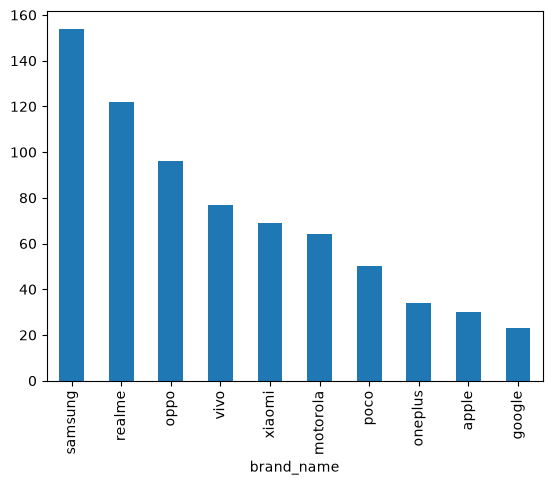

In [154]:
# plot a graph of top 5 brands
df1['brand_name'].value_counts().head(10).plot(kind='bar')

<Axes: >

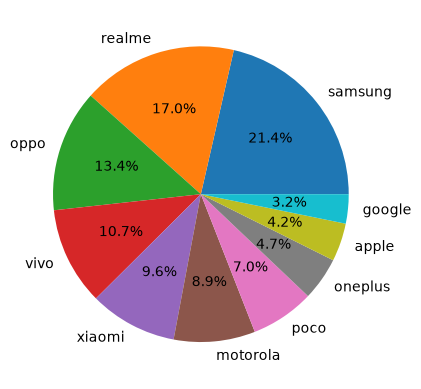

In [155]:
# pie chart
df1['brand_name'].value_counts().head(10).plot(kind='pie',autopct='%0.1f%%')

In [156]:
# model
df1['model'].nunique()

606

In [157]:
# price
df1['price'].describe()

count       888.000000
mean      38351.143018
std       34860.915165
min        5900.000000
25%       17990.000000
50%       26999.000000
75%       44999.000000
max      259999.000000
Name: price, dtype: float64

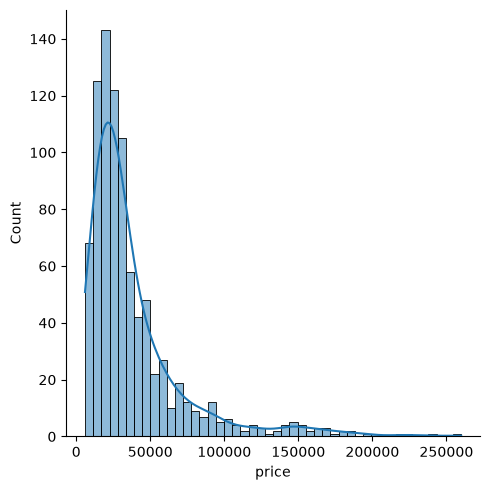

In [158]:
import seaborn as sns
sns.displot(kind='hist',data=df1,x='price',kde=True)

In [159]:
df1['price'].skew()

np.float64(2.627489456462036)

<Axes: ylabel='price'>

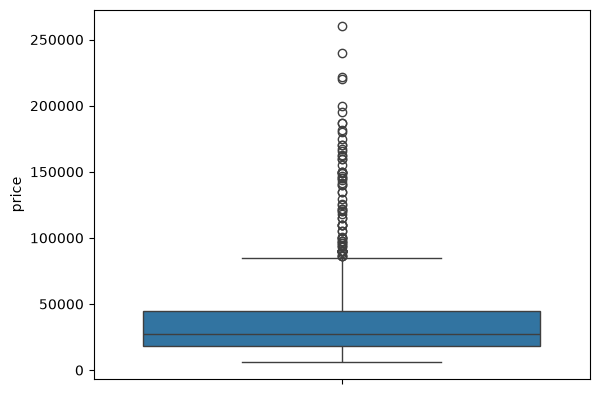

In [160]:
sns.boxplot(df1['price'])

In [161]:
df1[df1['price'] > 221900]

,brand_name,model,price,rating,has_5g,has_nfc,has_ir_blaster,processor_brand,num_core,processor_speed,...,num_of_front_camera,screen_resolution,refresh_rate,fast_charging_available,charging_capacity,primary_camera_rear,primary_camera_front,extended_memory_available,extended_upto,resolution_type
420,samsung,Samsung Galaxy Z Fold 8 Ultra,259999,NaN,True,True,False,qualcomm,8.0,4.74,...,2.0,2256 x 2504,120,NaN,45.0,200.0,10.0,0,NaN,2K
640,samsung,Samsung Galaxy Z Fold 8,239999,NaN,True,True,False,qualcomm,8.0,4.74,...,2.0,1828 x 2448,120,NaN,45.0,50.0,10.0,0,NaN,2K


In [162]:
df1['price'].isnull().sum()

np.int64(0)

In [163]:
df1['rating'].describe()

count    629.000000
mean      63.626391
std        7.951405
min       50.000000
25%       57.000000
50%       64.000000
75%       70.000000
max       79.000000
Name: rating, dtype: float64

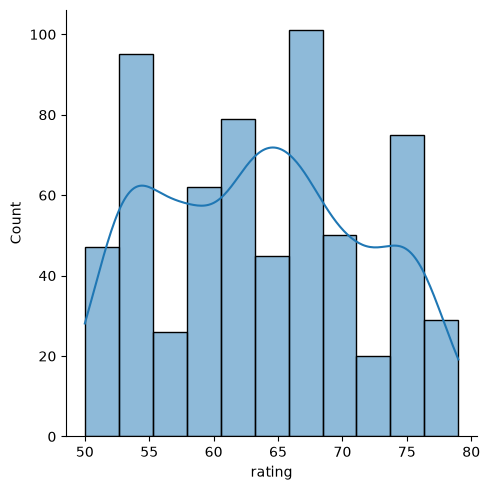

In [164]:
sns.displot(kind='hist',data=df1,x='rating',kde=True)

In [165]:
df1['rating'].skew()

np.float64(0.10681146232178756)

<Axes: ylabel='rating'>

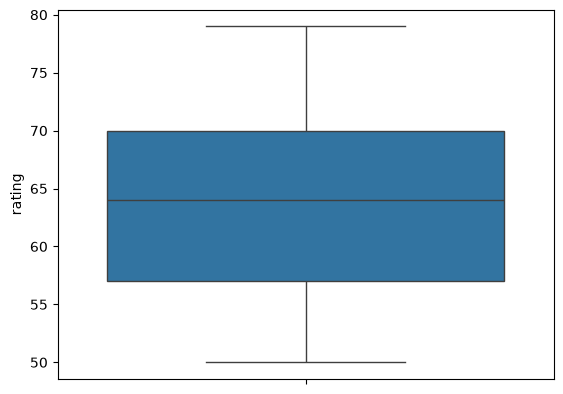

In [166]:
sns.boxplot(df1['rating'])

In [167]:
df['rating'].isnull().sum()

np.int64(391)

<Axes: >

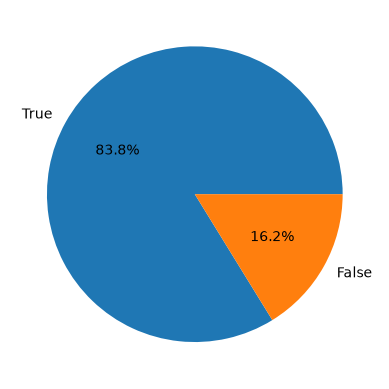

In [168]:
# has_5g
df1['has_5g'].value_counts().plot(kind='pie',autopct='%0.1f%%')

<Axes: >

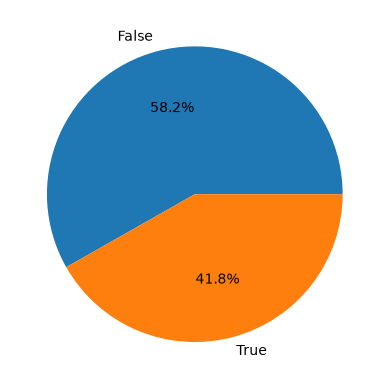

In [169]:
# has_nfc
df1['has_nfc'].value_counts().plot(kind='pie',autopct='%0.1f%%')

<Axes: >

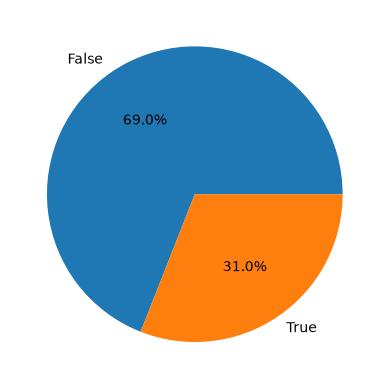

In [170]:
# has_ir_balster
df1['has_ir_blaster'].value_counts().plot(kind='pie',autopct='%0.1f%%')

In [171]:
df1[df1['has_ir_blaster']]['brand_name'].value_counts()

brand_name
xiaomi     57
oppo       51
vivo       41
poco       35
realme     26
oneplus    22
tecno      15
infinix    12
iqoo       10
itel        5
lava        1
Name: count, dtype: int64

<Axes: >

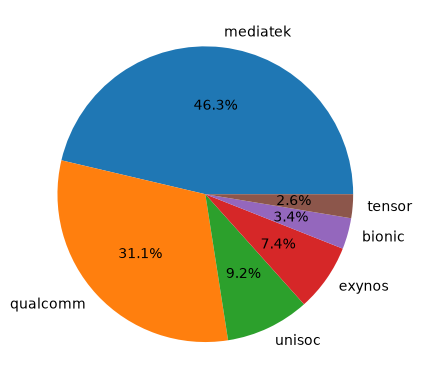

In [172]:
df1['processor_brand'].value_counts().plot(kind='pie',autopct='%0.1f%%')

<Axes: >

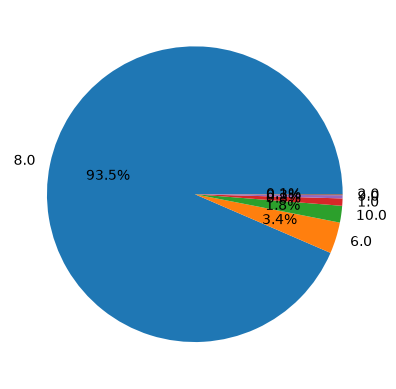

In [173]:
df1['num_core'].value_counts().plot(kind='pie',autopct='%0.1f%%')

In [174]:
df1['fast_charging_available'].value_counts()

fast_charging_available
0.0    29
Name: count, dtype: int64

<Axes: >

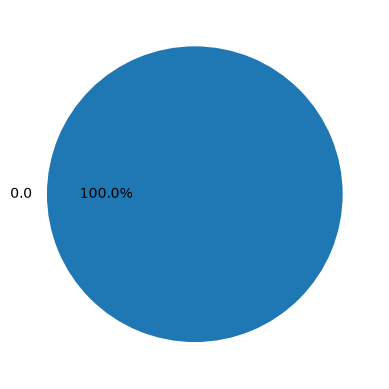

In [175]:
df1['fast_charging_available'].value_counts().plot(kind='pie',autopct='%0.1f%%')

<Axes: >

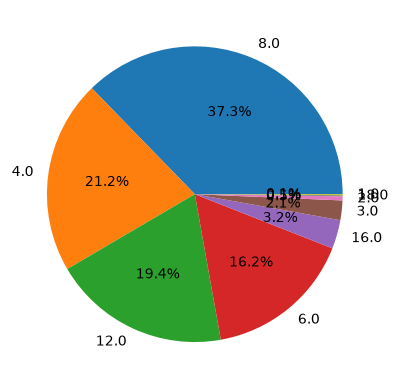

In [176]:
df1['ram_capacity'].value_counts().plot(kind='pie',autopct='%0.1f%%')

<Axes: >

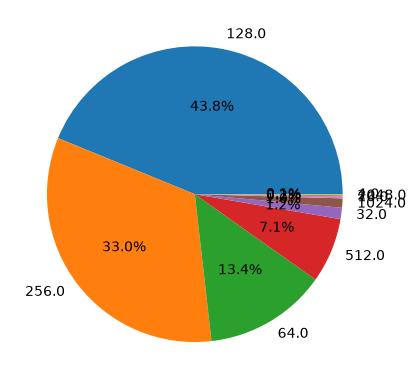

In [177]:
df1['internal_memory'].value_counts().plot(kind='pie',autopct='%0.1f%%')

<Axes: >

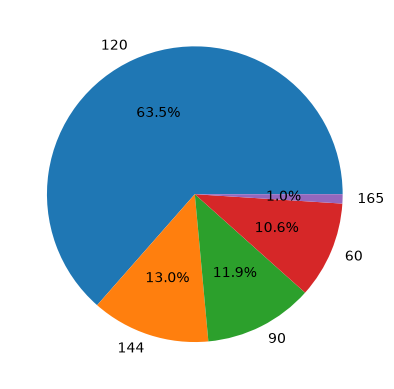

In [178]:
df1['refresh_rate'].value_counts().plot(kind='pie',autopct='%0.1f%%')

In [179]:
df1['refresh_rate'].value_counts()

refresh_rate
120    564
144    115
90     106
60      94
165      9
Name: count, dtype: int64

<Axes: >

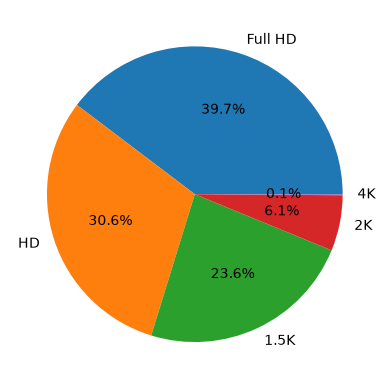

In [180]:
df1['resolution_type'].value_counts().plot(kind='pie',autopct='%0.1f%%')

<Axes: >

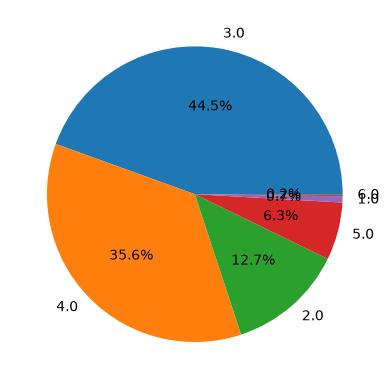

In [181]:
(df1['num_of_front_camera'] + df1['num_of_rear_cameras']).value_counts().plot(kind='pie',autopct='%0.1f%%')

<Axes: >

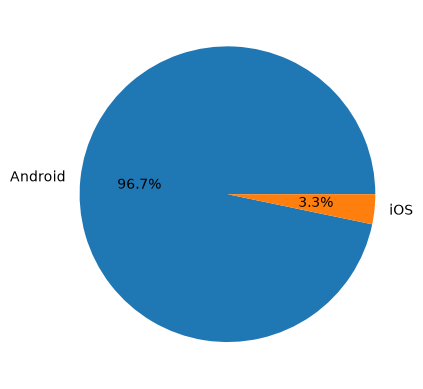

In [182]:
(df1['os']).value_counts().plot(kind='pie',autopct='%0.1f%%')

<Axes: >

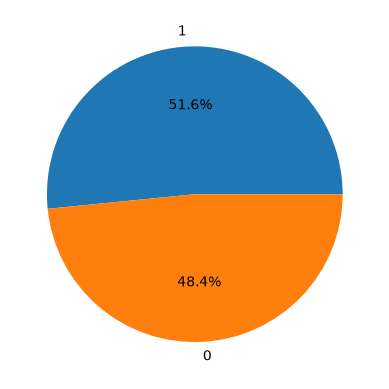

In [183]:
# extended_memory_available
df1['extended_memory_available'].value_counts().plot(kind='pie',autopct='%0.1f%%')

<Axes: >

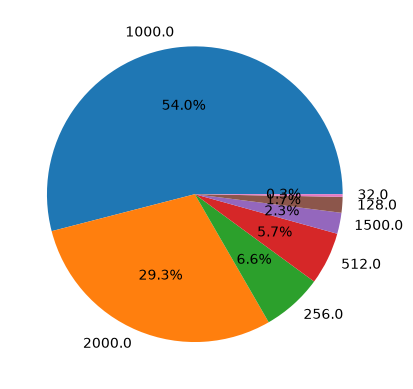

In [184]:
df1['extended_upto'].value_counts().plot(kind='pie',autopct='%0.1f%%')

In [185]:
def plot_graphs(column_name):
    sns.displot(kind='hist',kde=True,data=df1,x = column_name,label=column_name)
    sns.catplot(kind='box',data = df1,x = column_name)

In [186]:
columns_name = df1.select_dtypes(include=['float64','int64']).iloc[:,[3,6,12,7,13,14,16]].columns

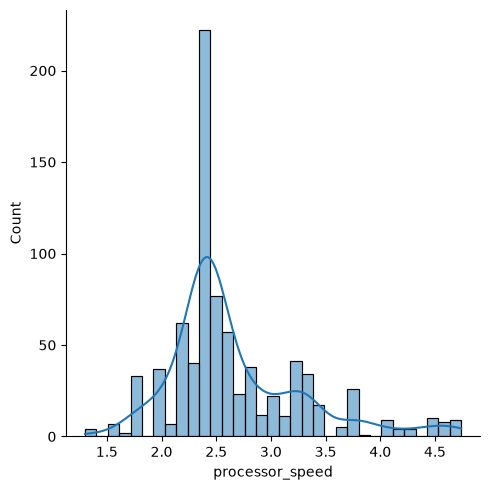

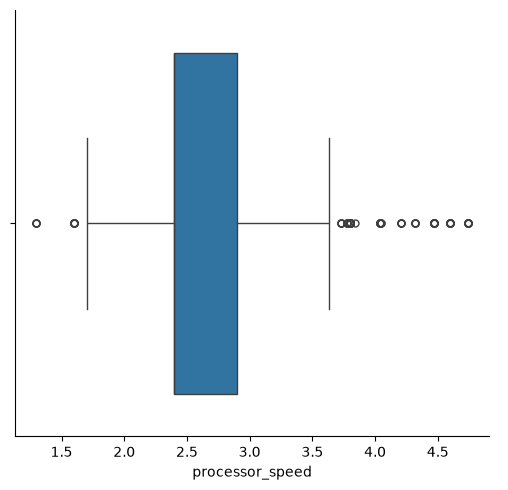

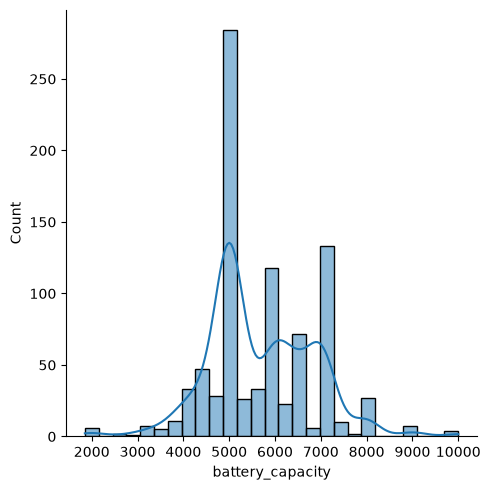

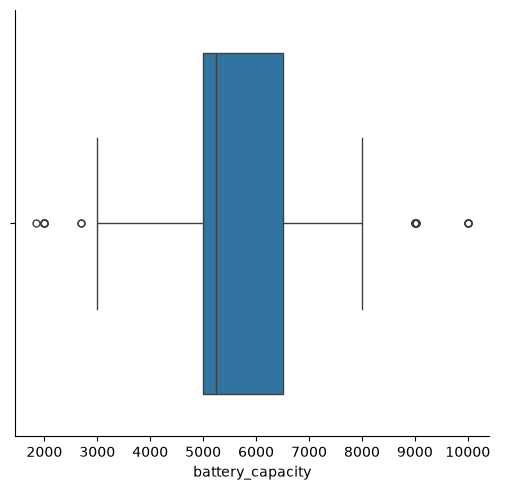

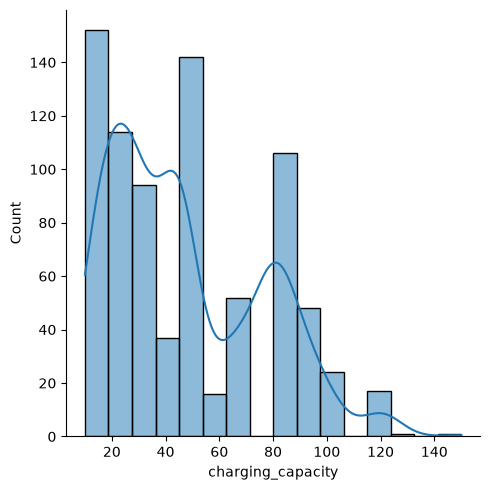

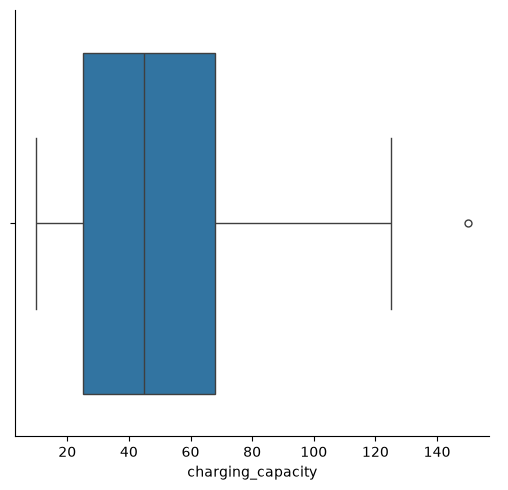

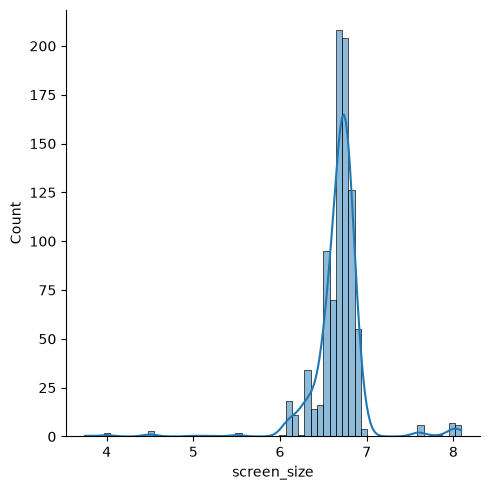

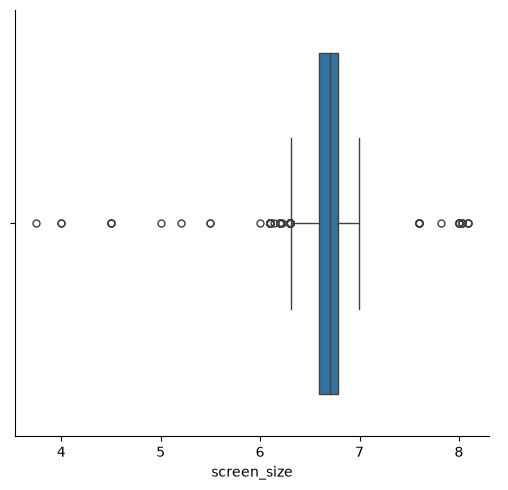

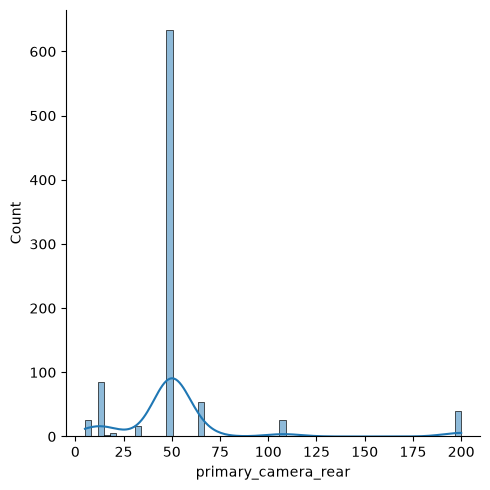

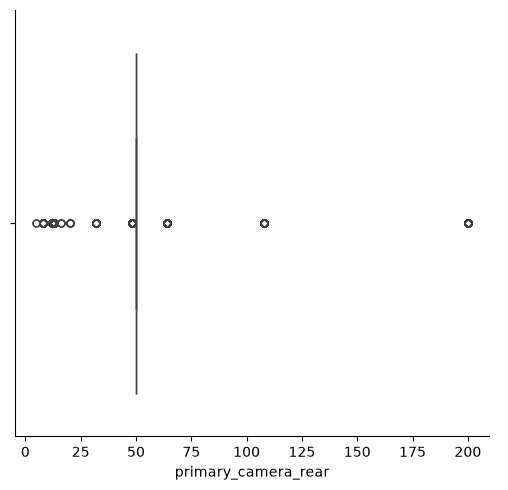

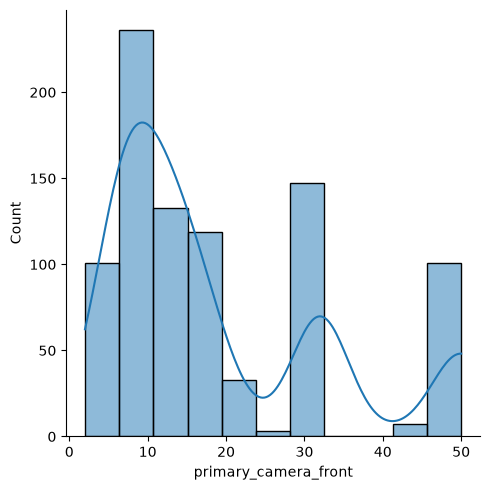

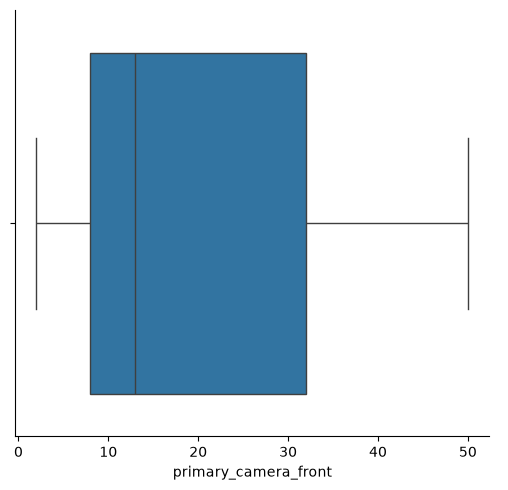

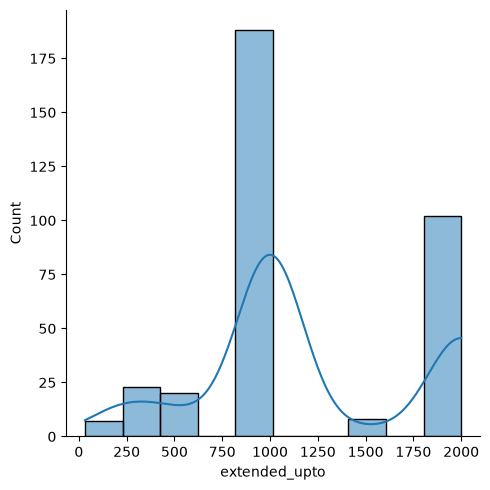

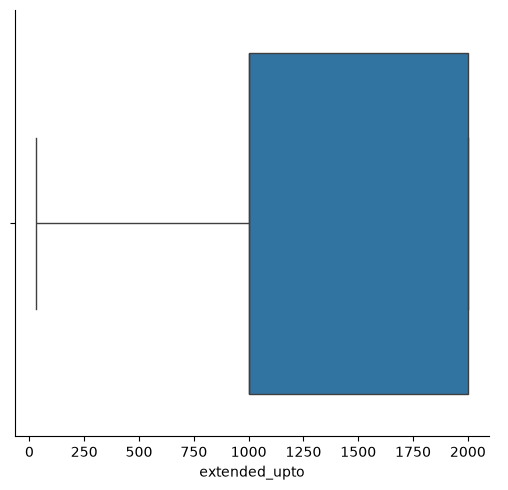

In [187]:
for col in columns_name:
    plot_graphs(col)

In [188]:
df1['extended_upto'].value_counts()

extended_upto
1000.0    188
2000.0    102
256.0      23
512.0      20
1500.0      8
128.0       6
32.0        1
Name: count, dtype: int64

In [189]:
x = df1.groupby('brand_name').count()['model']

In [190]:
temp_df = df1[df1['brand_name'].isin(x[x>10].index)].sort_values('price',ascending=False)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
 [Text(0, 0, 'apple'),
  Text(1, 0, 'google'),
  Text(2, 0, 'samsung'),
  Text(3, 0, 'oneplus'),
  Text(4, 0, 'vivo'),
  Text(5, 0, 'nothing'),
  Text(6, 0, 'oppo'),
  Text(7, 0, 'iqoo'),
  Text(8, 0, 'motorola'),
  Text(9, 0, 'xiaomi'),
  Text(10, 0, 'tecno'),
  Text(11, 0, 'realme'),
  Text(12, 0, 'infinix'),
  Text(13, 0, 'poco'),
  Text(14, 0, 'ai+'),
  Text(15, 0, 'lava')])

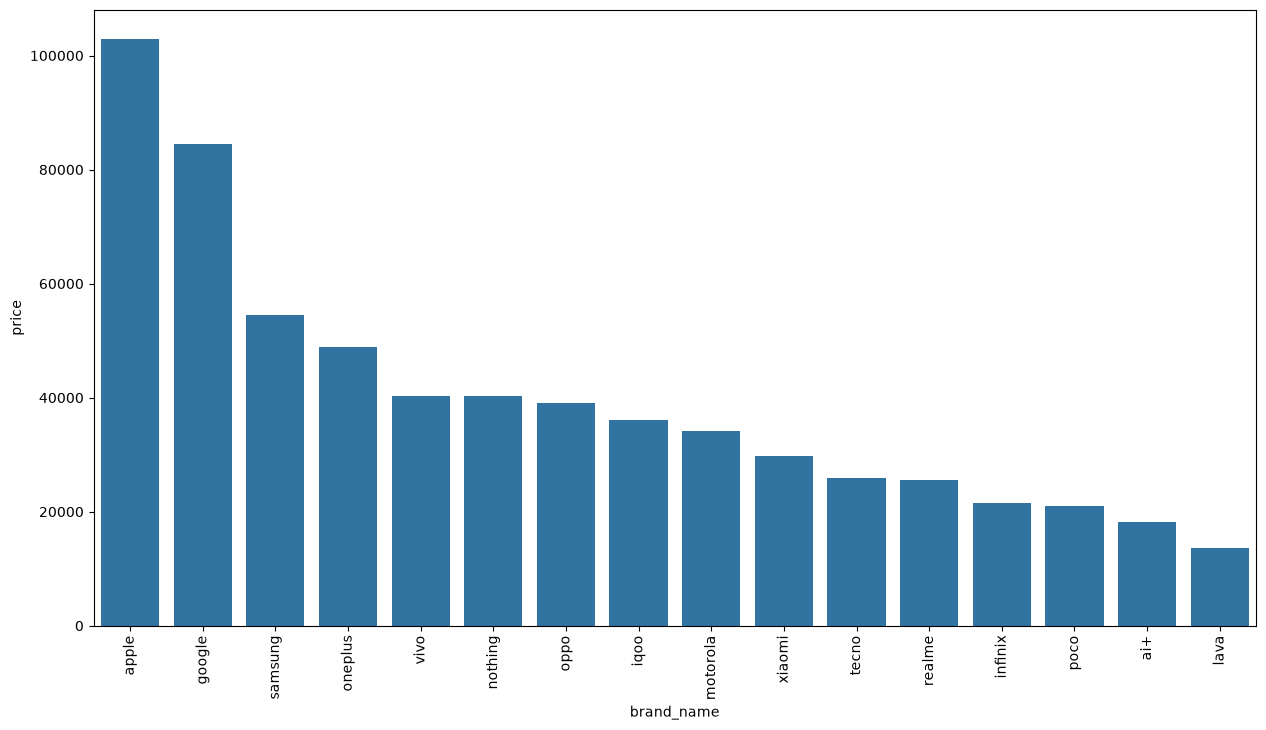

In [191]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,8))
sns.barplot(data=temp_df.groupby('brand_name')['price'].mean().sort_values(ascending=False).reset_index(),x='brand_name',y='price')
plt.xticks(rotation='vertical')

<Axes: xlabel='rating', ylabel='price'>

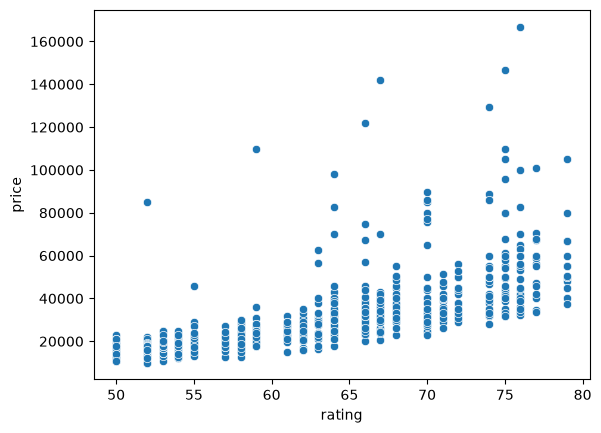

In [192]:
sns.scatterplot(data=df1,x='rating',y='price')

<Axes: xlabel='has_5g', ylabel='price'>

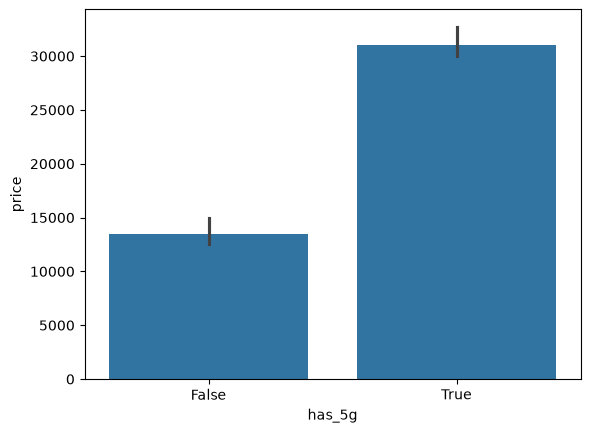

In [193]:
sns.barplot(data=temp_df,x='has_5g',y='price',estimator=np.median)

<Axes: xlabel='has_nfc', ylabel='price'>

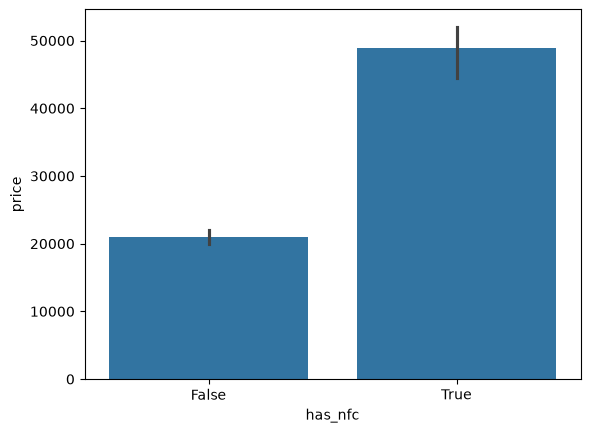

In [194]:
sns.barplot(data=temp_df,x='has_nfc',y='price',estimator=np.median)

<Axes: xlabel='has_ir_blaster', ylabel='price'>

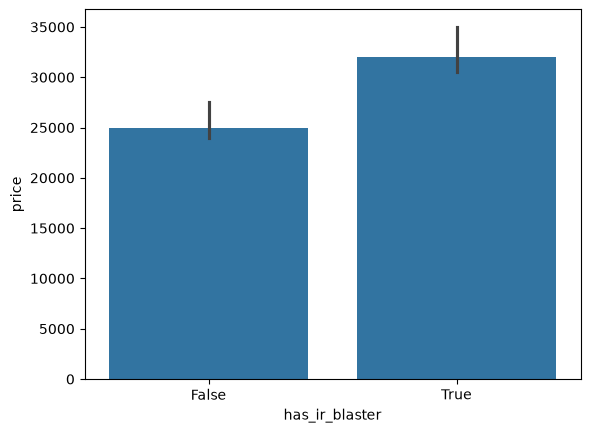

In [195]:
sns.barplot(data=temp_df,x='has_ir_blaster',y='price',estimator=np.median)

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'qualcomm'),
  Text(1, 0, 'bionic'),
  Text(2, 0, 'tensor'),
  Text(3, 0, 'exynos'),
  Text(4, 0, 'mediatek'),
  Text(5, 0, 'unisoc')])

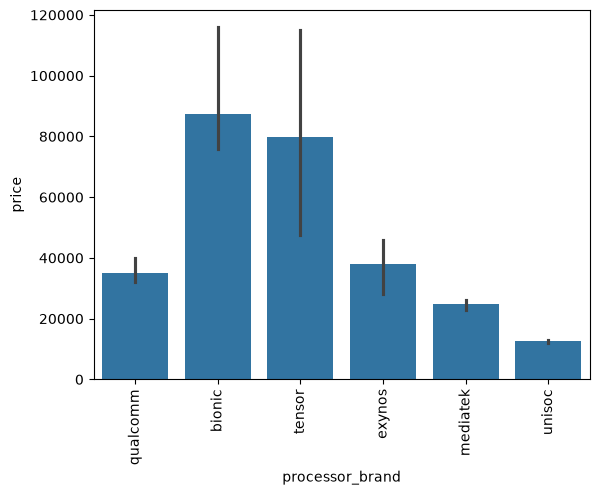

In [196]:
sns.barplot(data=temp_df,x='processor_brand',y='price',estimator=np.median)
plt.xticks(rotation='vertical')

<Axes: xlabel='num_core', ylabel='price'>

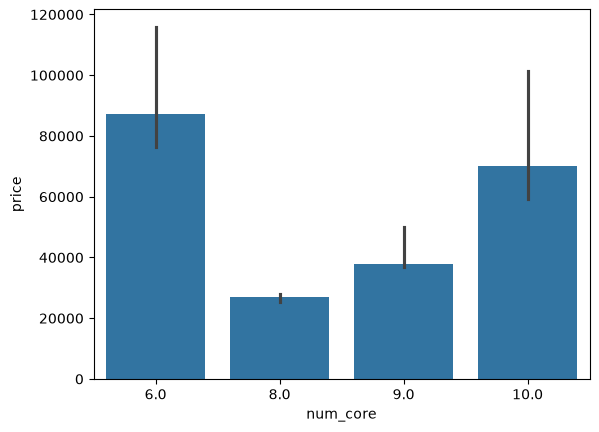

In [197]:
sns.barplot(data=temp_df,x='num_core',y='price',estimator=np.median)


In [203]:
pd.crosstab(df1['os'],df1['num_core'])

num_core,1.0,2.0,6.0,8.0,9.0,10.0
os,,,,,,
Android,7,1,1,820,3,16
iOS,0,0,29,0,0,0


<Axes: xlabel='processor_speed', ylabel='price'>

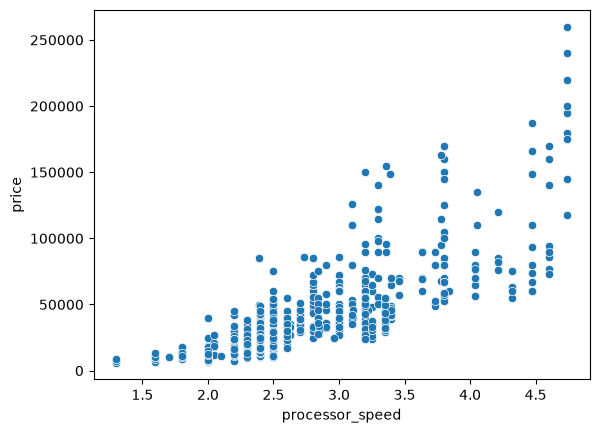

In [204]:
sns.scatterplot(data=df1,x='processor_speed',y='price')

<Axes: xlabel='ram_capacity', ylabel='price'>

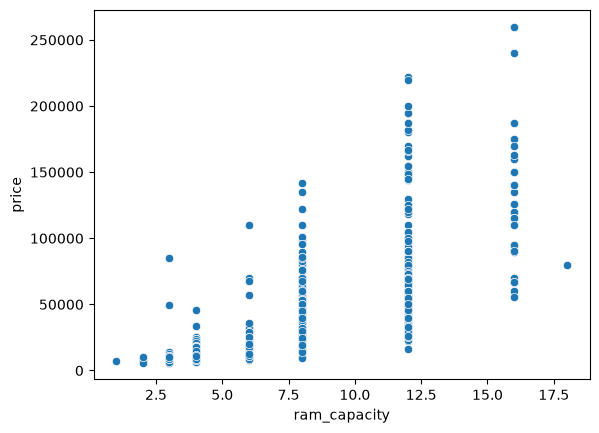

In [205]:
sns.scatterplot(data=df1,x='ram_capacity',y='price')

<Axes: xlabel='screen_size', ylabel='price'>

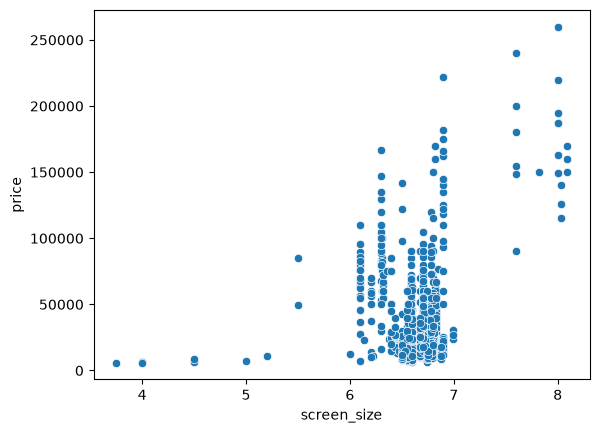

In [206]:
sns.scatterplot(data=df1,x='screen_size',y='price')

<Axes: >

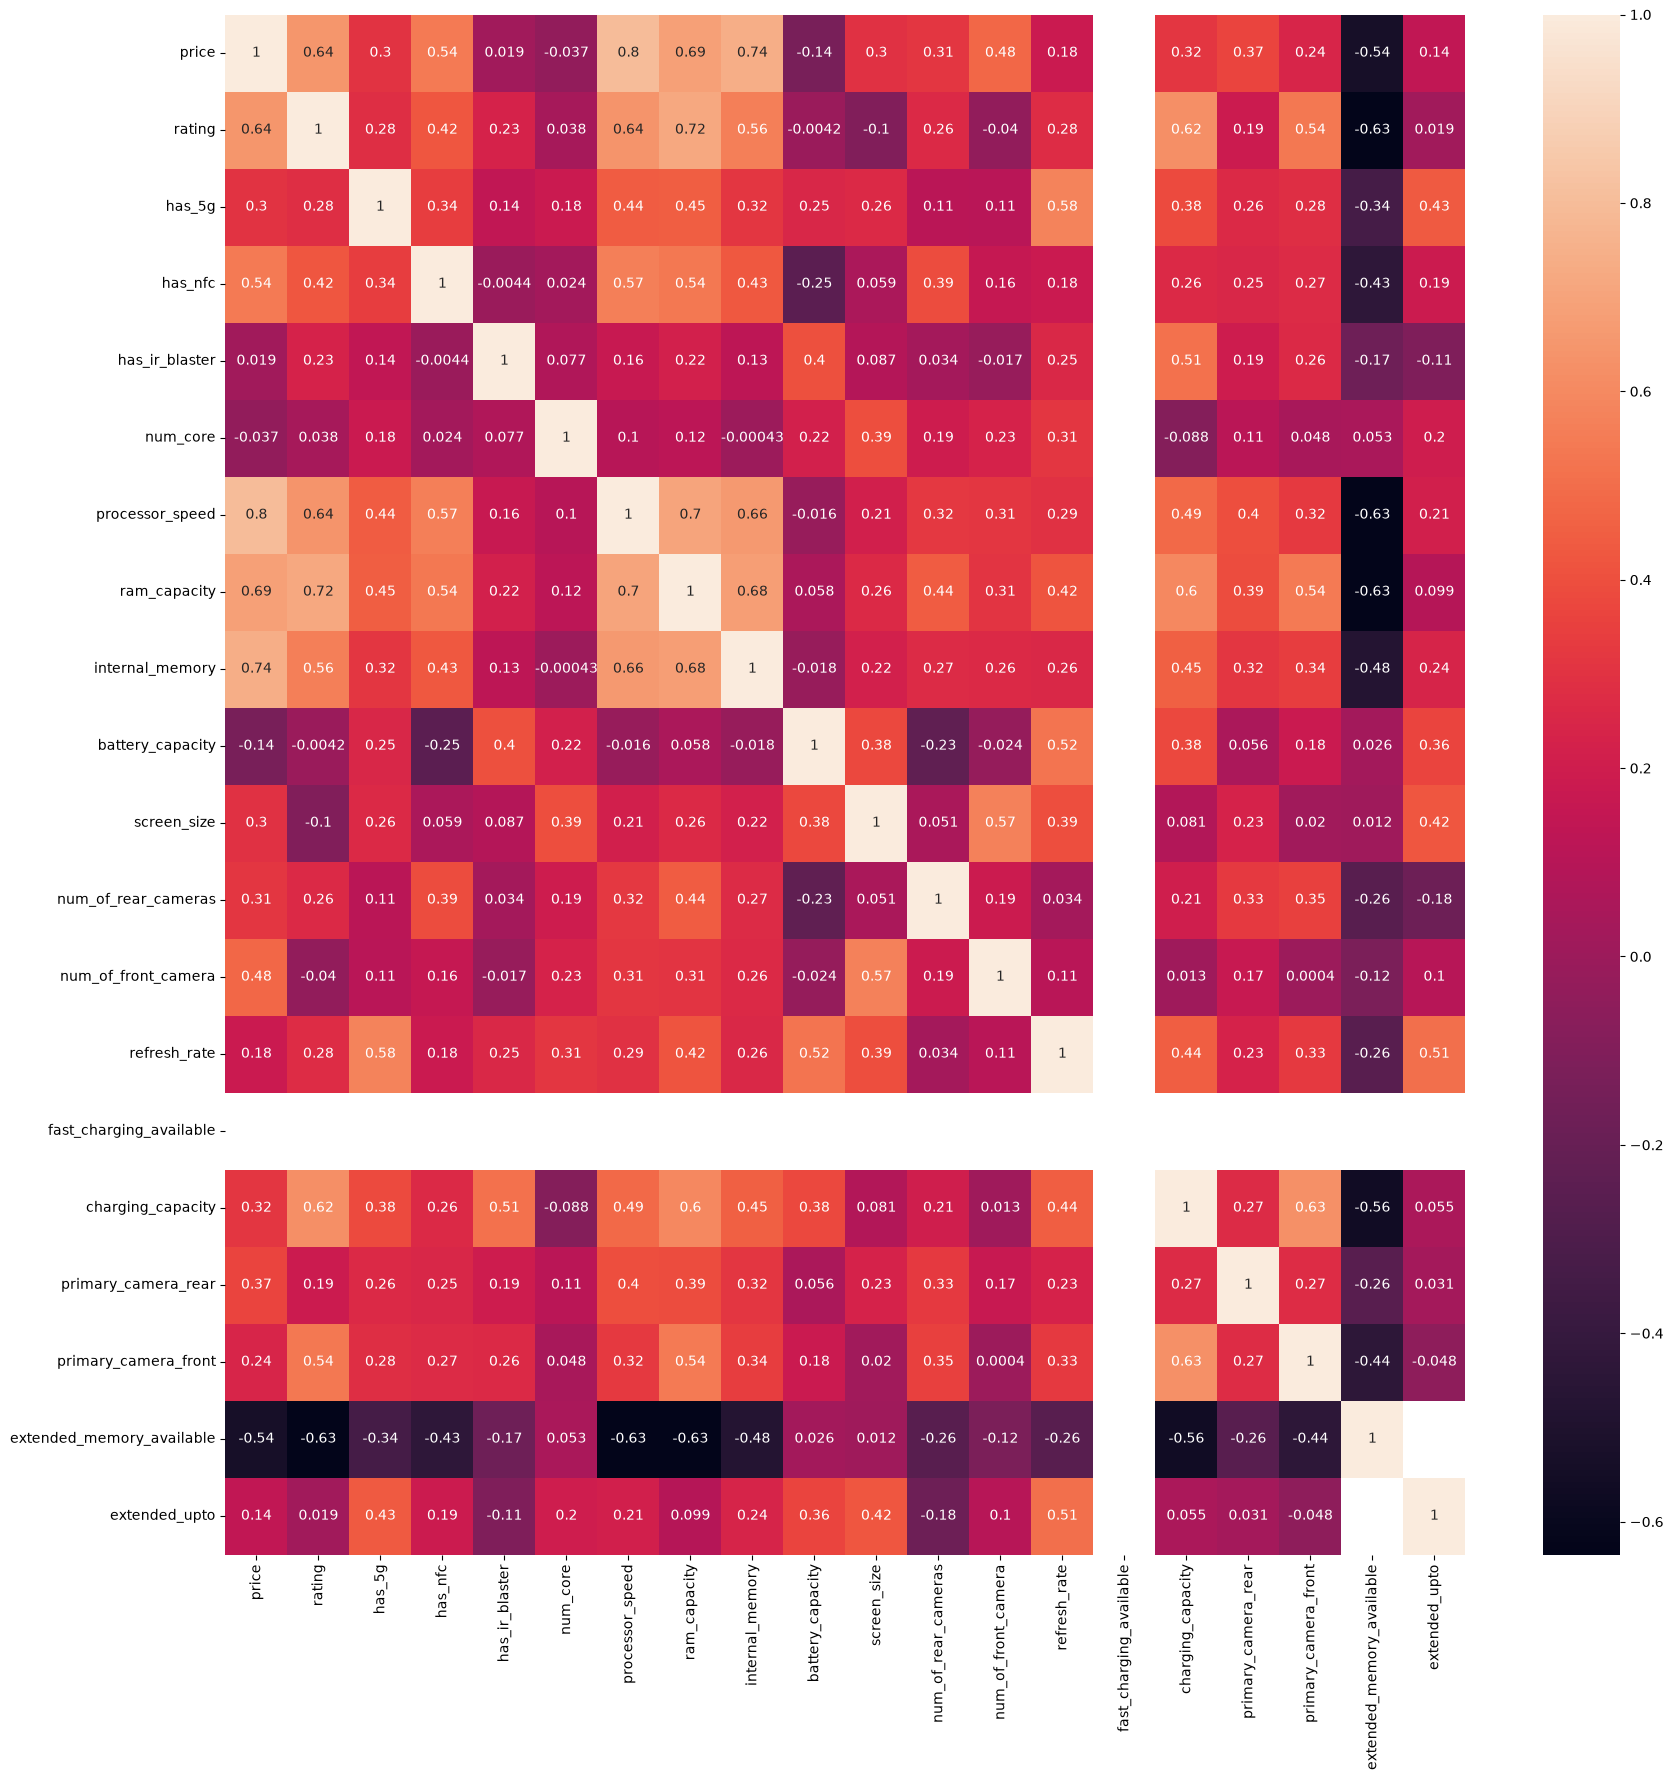

In [213]:
plt.figure(figsize=(20,20))
sns.heatmap(df1.corr(numeric_only=True),annot=True)

In [214]:
df1.corr(numeric_only=True)['price']

price                        1.000000
rating                       0.644050
has_5g                       0.300709
has_nfc                      0.541419
has_ir_blaster               0.019101
num_core                    -0.037226
processor_speed              0.801486
ram_capacity                 0.686083
internal_memory              0.741911
battery_capacity            -0.135416
screen_size                  0.296544
num_of_rear_cameras          0.314768
num_of_front_camera          0.481693
refresh_rate                 0.182196
fast_charging_available           NaN
charging_capacity            0.316366
primary_camera_rear          0.365346
primary_camera_front         0.242420
extended_memory_available   -0.537210
extended_upto                0.139703
Name: price, dtype: float64

In [215]:
df1.isnull().sum()

brand_name                     0
model                          0
price                          0
rating                       259
has_5g                         0
has_nfc                        0
has_ir_blaster                 0
processor_brand                5
num_core                      11
processor_speed               66
ram_capacity                   0
internal_memory                0
battery_capacity               3
fast_charging_capacity        29
os                             0
screen_size                    1
num_of_rear_cameras            0
num_of_front_camera            0
screen_resolution              1
refresh_rate                   0
fast_charging_available      859
charging_capacity             84
primary_camera_rear            1
primary_camera_front           8
extended_memory_available      0
extended_upto                540
resolution_type                1
dtype: int64

In [217]:
x_df = df1.select_dtypes(include=['int64','float64']).drop(columns='price')

In [218]:
x_df

,rating,num_core,processor_speed,ram_capacity,internal_memory,battery_capacity,screen_size,num_of_rear_cameras,num_of_front_camera,refresh_rate,fast_charging_available,charging_capacity,primary_camera_rear,primary_camera_front,extended_memory_available,extended_upto
0,72.0,8.0,2.80,8.0,256.0,6500.0,6.77,3,1.0,120,NaN,90.0,50.0,32.0,0,NaN
1,71.0,8.0,2.60,8.0,128.0,8000.0,6.78,2,1.0,144,NaN,80.0,50.0,16.0,0,NaN
2,53.0,8.0,2.30,4.0,64.0,6000.0,6.79,2,1.0,120,NaN,18.0,64.0,8.0,1,1000.0
3,70.0,8.0,2.70,8.0,128.0,7000.0,6.80,3,1.0,144,NaN,68.0,50.0,32.0,0,NaN
4,62.0,8.0,2.60,6.0,128.0,7000.0,6.72,2,1.0,144,NaN,45.0,50.0,8.0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
884,NaN,8.0,2.00,6.0,128.0,3410.0,6.00,1,1.0,60,0.0,NaN,13.0,8.0,1,NaN
885,52.0,6.0,2.39,3.0,256.0,2691.0,5.50,2,1.0,60,NaN,NaN,12.0,7.0,0,NaN
886,NaN,8.0,1.30,1.0,4.0,1850.0,5.00,1,1.0,60,0.0,NaN,8.0,2.0,1,32.0
887,NaN,1.0,1.30,4.0,64.0,3000.0,4.50,1,0.0,60,0.0,NaN,8.0,NaN,0,NaN


In [219]:
 from sklearn.impute import KNNImputer

In [251]:
imputer = KNNImputer(n_neighbors=5)
x_df_values = imputer.fit_transform(x_df)
x_df = pd.DataFrame(x_df_values,columns=x_df.columns)
x_df['price'] = df1['price']
a = x_df.corr()['price'].reset_index()
b = df1.corr(numeric_only=True)['price'].reset_index()
b.merge(a,on='index')

,index,price_x,price_y
0,price,1.000000,1.000000
1,rating,0.644050,0.370201
2,num_core,-0.037226,-0.015173
3,processor_speed,0.801486,0.500783
4,ram_capacity,0.686083,0.401065
5,internal_memory,0.741911,0.433947
6,battery_capacity,-0.135416,-0.067189
7,screen_size,0.296544,0.116286
8,num_of_rear_cameras,0.314768,0.206171
9,num_of_front_camera,0.481693,0.183244


In [261]:
pd.get_dummies(df1,columns=['brand_name','processor_brand','os'],drop_first=True).corr(numeric_only=True)['price'].sort_values(ascending=False)

price                        1.000000
processor_speed              0.801486
internal_memory              0.741911
ram_capacity                 0.686083
rating                       0.644050
has_nfc                      0.541419
num_of_front_camera          0.481693
primary_camera_rear          0.365346
brand_name_apple             0.346412
os_iOS                       0.345103
charging_capacity            0.316366
num_of_rear_cameras          0.314768
has_5g                       0.300709
screen_size                  0.296544
primary_camera_front         0.242420
processor_brand_qualcomm     0.227531
brand_name_google            0.215879
processor_brand_tensor       0.215879
brand_name_samsung           0.212572
refresh_rate                 0.182196
extended_upto                0.139703
processor_brand_exynos       0.065603
brand_name_oneplus           0.059900
brand_name_asus              0.040136
has_ir_blaster               0.019101
brand_name_vivo              0.017242
brand_name_n